## check on cutflow

In [83]:
]

dict_keys(['WJets(c)', '$t\\bar{t}$(c)', 'ST(c)', 'DY(c)', 'VV(c)', 'WJets(b)', '$t\\bar{t}$(b)', 'ST(b)', 'DY(b)', 'VV(b)', 'WJets(udsg)', '$t\\bar{t}$(udsg)', 'ST(udsg)', 'DY(udsg)', 'VV(udsg)', 'WJets(pu)', '$t\\bar{t}$(pu)', 'ST(pu)', 'DY(pu)', 'VV(pu)', 'data'])

In [15]:
from coffea.util import load
signal_pre16=load("tt_fixHLT_preVFP_UL16_v00/output.coffea")
signal_post16=load("tt_fixHLT_postVFP_UL16_v00/output.coffea")
signal_18=load("tt_fixHLT_UL18_v01/output.coffea")
signal_17=load("MC_fixHLT_UL17_v00/output_0_1.coffea")

mc='HPlusCharm_4FS_MuRFScaleDynX0p50_HToWWTo2L2Nu_M125_TuneCP5_13TeV-amcatnloFXFX-pythia8'

In [21]:
print("\tpreVFP16\tpostVFP16\tUL17\tUL18")
for i in ['global selection', 'signal region', 'jet kinematics', 'jet dr_cand1', 'jet dr_cand2','jet id', 'jet CvB', 'jet CvL', 'all emu']:
    print(i,round(signal_pre16[mc]['cutflow'][i]/signal_pre16[mc]['cutflow']['all']*100,2),round(signal_post16[mc]['cutflow'][i]/signal_post16[mc]['cutflow']['all']*100,2),round(signal_17[mc]['cutflow'][i]/signal_17[mc]['cutflow']['all']*100,2),round(signal_18[mc]['cutflow'][i]/signal_18[mc]['cutflow']['all']*100,2))

	preVFP16	postVFP16	UL17	UL18
global selection 1.23 1.31 1.14 1.16
signal region 1.14 1.21 1.06 1.08
jet kinematics 1.14 1.21 1.06 1.08
jet dr_cand1 1.0 1.06 0.94 0.97
jet dr_cand2 0.39 0.43 0.42 0.41
jet id 0.28 0.32 0.29 0.28
jet CvB 0.26 0.29 0.26 0.26
jet CvL 0.09 0.11 0.1 0.1
all emu 0.09 0.11 0.1 0.1


## plotter

In [1]:
from coffea.util import load
import matplotlib.pyplot as plt
import mplhep as hep
from BTVNanoCommissioning.utils.xs_scaler import collate
from BTVNanoCommissioning.utils.plot_utils import load_coffea
import numpy as np
from BTVNanoCommissioning.helpers.xsection import xsection
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt, mplhep as hep
from BTVNanoCommissioning.utils.plot_utils import (
    isin_dict,
    check_config,
    load_coffea,
    load_default,
    rebin_and_xlabel,
    plotratio,
    errband_opts,
    autoranger,
)

In [22]:
output=load_coffea({"input":"MC_fixHLT_UL17_v00/*.coffea","lumi":41500},True)

In [23]:
syst_list=['ttbar_weight',
 'PDFaS_weight',
 'ele_ID_2017',
 'mu_Iso_2017',
 'puweight_2017',
 'mu_ID_2017',
 'ele_Reco_2017',
 'mu_Reco_2017',
  'aS_weight',
 'L1prefireweight',
 'DeepJetC_Interp',
 'scalevar_3pt',
 'DeepJetC_PSWeightISR',
 'DeepJetC_jesTotal',
 'DeepJetC_Stat_2017',
 'UEPS_FSR',
 'DeepJetC_PSWeightFSR',

 'PDF_weight',
 'DeepJetC_XSec_BRUnc_WJets_c',
 'DeepJetC_XSec_BRUnc_DYJets_b',
 'DeepJetC_Extrap',
 'DeepJetC_LHEScaleWeight_muR',
 'DeepJetC_PUWeight',
 'DeepJetC_jer',
 
 'DeepJetC_XSec_BRUnc_DYJets_c',
 'scalevar_7pt',
 'UEPS_ISR',
 'DeepJetC_LHEScaleWeight_muF',
"JES_FlavorQCD",
"JES_RelativeBal",
"JES_HF",
"JES_BBEC1",
"JES_EC2",
"JES_Absolute",
    "JES_jes",
"JES_Absolute_2017",
"JES_HF_2017",
"JES_EC2_2017",
"JES_RelativeSample_2017",
"JES_BBEC1_2017",
#  'JES_2017',
 'UES_2017',
 'JER_2017']
# corr_sys=[]
axes={'flav':sum,'lepflav':'emu'}
var={'top_CR_lowmT':"template_mTh",'SR_HM':"template_BDT_SR_HM",'SR_LM':"template_BDT_SR_LM",'SR2_LM':"template_BDT_SR2_LM"}

collated=collate(output,{"hc":["HPlusCharm_4FS_MuRFScaleDynX0p50_HToWWTo2L2Nu_M125_TuneCP5_13TeV-amcatnloFXFX-pythia8"]})

In [24]:
import hist
import mplhep as hep
import uproot 
# year=["2016_preVFP","2016_postVFP","2017","2018"]
year="2017"
for r in var.keys():
    root_out=uproot.recreate(f"../card_maker/shape/{year}_{r}_{var[r]}_0607_off.root")

    for s in collated.keys():
        axes['syst']='nominal'
        axes['region']=r
        print(r,s,var[r])
        syst_list_in_file=[collated[s][var[r]].axes[0].value(i) for i in range(1,collated[s][var[r]].axes[0].size)]
        root_out[s]=collated[s][var[r]][axes]
        if s!="data_obs":
            for sys in syst_list:
                if sys.endswith("2017"):sys= sys.replace("2017",year)
                if "2018" in year and sys =="L1prefireweight" : continue
                for v in ["Up","Down"]:
                    
                    if ("JES" in sys)and "2016" in year:
                        sys = sys.replace("_preVFP","").replace("_postVFP","")
                        axes['syst']=sys+v
                        print(sys,axes)

                    elif "JES" not in sys and sys.endswith(year): axes['syst']=sys[:sys.find(year)-1]+v
                    else:axes['syst']=sys+v
                    
                    prefix = "_13TeV"
#                     print(r,s,var[r],axes)
                
                        
                            
                    if 'ttbar_' in sys:
                        if s=='ttbar':
                            root_out[f'{s}_CMS_{sys}{prefix}{v}']=collated[s][var[r]][axes]
                        else :
                            axes['syst']='nominal'
                            root_out[f'{s}_CMS_{sys}{prefix}{v}']=collated[s][var[r]][axes]
                    elif 'scalevar_3pt' == sys or 'UEPS_FSR'==sys or 'UEPS_ISR'==sys:root_out[f'{s}_CMS_{sys}_{s}{prefix}{v}']=collated[s][var[r]][axes]
                    elif ("JER" in sys or "UES" in sys) and "2016" in year:root_out[f'{s}_CMS_{sys.replace("_preVFP","").replace("_postVFP","")}{prefix}{v}']=collated[s][var[r]][axes]
                    else:root_out[f'{s}_CMS_{sys}{prefix}{v}']=collated[s][var[r]][axes]

            

top_CR_lowmT hc template_mTh
SR_HM hc template_BDT_SR_HM
SR_LM hc template_BDT_SR_LM
SR2_LM hc template_BDT_SR2_LM


In [25]:
var={'top_CR_lowmT':"template_mTh",'SR_HM':"template_BDT_SR_HM",'SR_LM':"template_BDT_SR_LM",'SR2_LM':"template_BDT_SR2_LM"}
for r in var.keys():
    fold=uproot.open(f"../card_maker/shape/2017_{r}_{var[r]}_0507_splitJEC.root")
    f=uproot.update(f"../card_maker/shape/2017_{r}_{var[r]}_0607_off.root")
    for h in fold.keys():
        if h in f.keys():continue
        f[h.replace(";1","")]=fold[h]

(array([0., 6., 6., 8., 3., 0., 1., 0., 0., 0.]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 [<matplotlib.patches.Polygon at 0x7f19794f4790>])

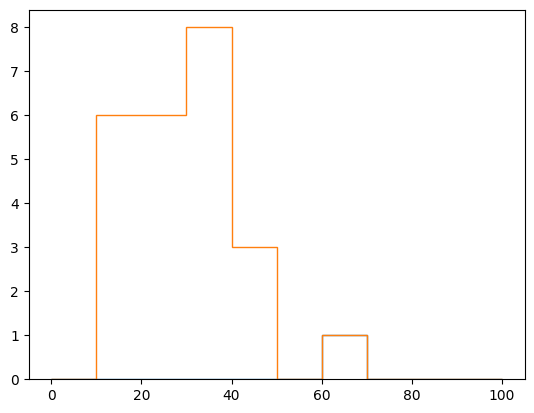

In [14]:
plt.hist(out2['gchcWW2L2Nu_4f']['array']['top_CR']['emu']['ll_mass'].value,bins=10,range=(0,100),histtype='step')
plt.hist(out2['gchcWW2L2Nu_4f']['array']['top_CR_lowmT']['emu']['ll_mass'].value,bins=10,range=(0,100),histtype='step')

## other check

In [ ]:
import uproot
import mplhep as hep
import matplotlib.pyplot as plt
plt.style.use(hep.style.ROOT)
cats = {
    "old":["SR","all"],
    "newBDT_2class_old_def":["SR","all","all_lowmT"],
    "newBDT_2class_wide":["SR_LM","SR_HM","all","all_lowmT"],
    "newBDT_2class_wide_2j":["SR_LM","SR","all","all_lowmT"],
    "newBDT_3class_old_def":["SR","all","all_lowmT"],
    "newBDT_3class_wide":["SR2_LM","SR","all","all_lowmT"],
    "newBDT_3class_wide_2j":["SR2_LM","SR","all","all_lowmT"],
    }
fig,ax=plt.subplots()
medlim,error1,error2={},{},{}
for i,cat in enumerate(cats.keys()):
    reg="SR"
    f=uproot.open(f"../card_maker/newbin/higgsCombine{cat}_2017_hc_emu_{reg}_13TeV.AsymptoticLimits.mH125.root")
    limit = f["limit"]["limit"].array()
    print(cat,reg,limit)
    medlim[cat]=limit[2]
    error2[cat]=[limit[2]-limit[0],limit[4]-limit[2]]
    error1[cat]= [limit[2]-limit[1],limit[3]-limit[2]]
print(error2,error1)
ax.errorbar([medlim[cat] for cat in medlim.keys()],[i for i in range(len(medlim.keys()))],
             xerr = [[error2[cat][0] for cat in medlim.keys()],[error2[cat][1] for cat in medlim.keys()]],
             fmt ='o',markerfacecolor='k',ecolor='y',lw=4)
ax.errorbar( [medlim[cat] for cat in medlim.keys()],[i for i in range(len(medlim.keys()))],
             xerr = [[error1[cat][0] for cat in medlim.keys()],[error1[cat][1] for cat in medlim.keys()]],
             fmt ='o',ecolor='g',lw=4,markersize=0)
ax.set_yticklabels(["","old\n(N=2)","2class(nJ)\n(N=2)","2class($m_{\\ell\\ell}$)\n(N=2)","2class($m_{\\ell\\ell}$+2J)\n(N=3)","3class(nJ)\n(N=6)","3class($m_{\\ell\\ell}$)\n(N=4)","3class($m_{\\ell\\ell}$+2J)\n(N=7)"])
ax.set_title("SR")
# plt.errorbar(0.5+i, limit[2],
#          yerr =,
#          marker_size=0,ecolor=pre_color)

old all [196, 268, 393, 591, 881]
newBDT_2class_old_def all [195, 269, 391, 593, 886]
newBDT_2class_wide all [214, 291, 424, 642, 958]
newBDT_2class_wide_2j all [195, 267, 391, 591, 883]
newBDT_3class_old_def all [198, 271, 396, 599, 895]
newBDT_3class_wide all [208, 284, 416, 628, 939]
newBDT_3class_wide_2j all [197, 271, 395, 597, 894]
{'old': [196.2890625, 488.1973876953125], 'newBDT_2class_old_def': [195.3125, 495.16558837890625], 'newBDT_2class_wide': [210.25848388671875, 533.8692626953125], 'newBDT_2class_wide_2j': [195.3125, 492.04541015625], 'newBDT_3class_old_def': [198.2421875, 498.61737060546875], 'newBDT_3class_wide': [208.0078125, 523.1798095703125], 'newBDT_3class_wide_2j': [197.265625, 499.31866455078125]} {'old': [124.21417236328125, 198.73382568359375], 'newBDT_2class_old_def': [122.0703125, 202.416259765625], 'newBDT_2class_wide': [133.05419921875, 217.9322509765625], 'newBDT_2class_wide_2j': [123.59619140625, 200.85919189453125], 'newBDT_3class_old_def': [125.4501342

/tmp/ipykernel_53900/2746700964.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(["","old\n(N=3)","2class(nJ)\n(N=3)","2class($m_{\\ell\\ell}$)\n(N=3)","2class($m_{\\ell\\ell}$+2J)\n(N=8)","3class(nJ)\n(N=7)","3class($m_{\\ell\\ell}$)\n(N=5)","3class($m_{\\ell\\ell}$+2J)\n(N=8)"])


Text(0.5, 1.0, 'all')

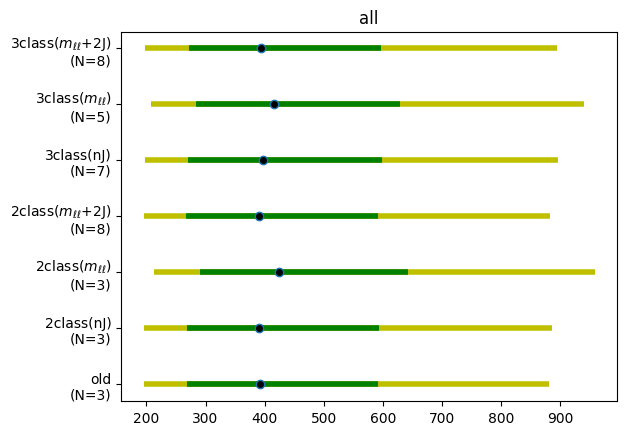

In [23]:
import uproot
import matplotlib.pyplot as plt
cats = {
    "old":["SR","all"],
    "newBDT_2class_old_def":["SR","all","all_lowmT"],
    "newBDT_2class_wide":["SR_LM","SR_HM","all","all_lowmT"],
    "newBDT_2class_wide_2j":["SR_LM","SR","all","all_lowmT"],
    "newBDT_3class_old_def":["SR","all","all_lowmT"],
    "newBDT_3class_wide":["SR2_LM","SR","all","all_lowmT"],
    "newBDT_3class_wide_2j":["SR2_LM","SR","all","all_lowmT"],
    }
fig,ax=plt.subplots()
medlim,error1,error2={},{},{}
for i,cat in enumerate(cats.keys()):
    reg="all"
    f=uproot.open(f"../card_maker/newbin/higgsCombine{cat}_2017_hc_emu_{reg}_13TeV.AsymptoticLimits.mH125.root")
    limit = f["limit"]["limit"].array()
    print(cat,reg,limit)
    medlim[cat]=limit[2]
    error2[cat]=[limit[2]-limit[0],limit[4]-limit[2]]
    error1[cat]= [limit[2]-limit[1],limit[3]-limit[2]]
print(error2,error1)
ax.errorbar([medlim[cat] for cat in medlim.keys()],[i for i in range(len(medlim.keys()))],
             xerr = [[error2[cat][0] for cat in medlim.keys()],[error2[cat][1] for cat in medlim.keys()]],
             fmt ='o',markerfacecolor='k',ecolor='y',lw=4)
ax.errorbar( [medlim[cat] for cat in medlim.keys()],[i for i in range(len(medlim.keys()))],
             xerr = [[error1[cat][0] for cat in medlim.keys()],[error1[cat][1] for cat in medlim.keys()]],
             fmt ='o',ecolor='g',lw=4,markersize=0)
ax.set_yticklabels(["","old\n(N=3)","2class(nJ)\n(N=3)","2class($m_{\\ell\\ell}$)\n(N=3)","2class($m_{\\ell\\ell}$+2J)\n(N=8)","3class(nJ)\n(N=7)","3class($m_{\\ell\\ell}$)\n(N=5)","3class($m_{\\ell\\ell}$+2J)\n(N=8)"])
ax.set_title("all")
# plt.errorbar(0.5+i, limit[2],
#          yerr =,
#          marker_size=0,ecolor=pre_color)

In [42]:
import pandas as pd
d={  
    "old (N=2)":["nJ=1","nJ>1","","","","",""], 
    "2class(nJ) (N=2)":["nJ=1","nJ>1","","","","",""], 
    "2class($m_{\\ell\\ell}$) (N=2)":["$m_{\\ell\\ell}\geq76GeV$","$m_{\\ell\\ell}<76GeV$","","","","",""], 
    "2class($m_{\\ell\\ell}$+2J) (N=3)":["$m_{\\ell\\ell}\geq76GeV$","$m_{\\ell\\ell}<76GeV$ nJ==1","$m_{\\ell\\ell}<76GeV$ nJ>1","","","",""],
    "3class(nJ) (N=6)":["nJ=1 Bkg node","nJ=1 HWW node","nJ=1 H+c node","nJ>1 Bkg node","nJ>1 HWW node","nJ>1 H+c node",""],
    "3class($m_{\\ell\\ell}$) (N=4)":["$m_{\\ell\\ell}\geq76GeV$","$m_{\\ell\\ell}<76GeV$ Bkg node","$m_{\\ell\\ell}<76GeV$ HWW node","$m_{\\ell\\ell}<76GeV$ H+c node","","",""],
    "3class($m_{\\ell\\ell}$+2J) (N=7)":["$m_{\\ell\\ell}\geq76GeV$","$m_{\\ell\\ell}<76GeV$ Bkg node nJ=1","$m_{\\ell\\ell}<76GeV$ HWW nodee nJ=1","$m_{\\ell\\ell}<$76GeV$ H+c nodee nJ=1","$m_{\\ell\\ell}<76GeV$ Bkg node nJ>1","$m_{\\ell\\ell}<76GeV$ HWW nodee nJ>1","$m_{\\ell\\ell}<$76GeV$ H+c nodee nJ>1"]}

df = pd.DataFrame(data=d).T.loc[::-1]
df

,0,1,2,3,4,5,6
3class($m_{\ell\ell}$+2J) (N=7),$m_{\ell\ell}\geq76GeV$,$m_{\ell\ell}<76GeV$ Bkg node nJ=1,$m_{\ell\ell}<76GeV$ HWW nodee nJ=1,$m_{\ell\ell}<$76GeV$ H+c nodee nJ=1,$m_{\ell\ell}<76GeV$ Bkg node nJ>1,$m_{\ell\ell}<76GeV$ HWW nodee nJ>1,$m_{\ell\ell}<$76GeV$ H+c nodee nJ>1
3class($m_{\ell\ell}$) (N=4),$m_{\ell\ell}\geq76GeV$,$m_{\ell\ell}<76GeV$ Bkg node,$m_{\ell\ell}<76GeV$ HWW node,$m_{\ell\ell}<76GeV$ H+c node,,,
3class(nJ) (N=6),nJ=1 Bkg node,nJ=1 HWW node,nJ=1 H+c node,nJ>1 Bkg node,nJ>1 HWW node,nJ>1 H+c node,
2class($m_{\ell\ell}$+2J) (N=3),$m_{\ell\ell}\geq76GeV$,$m_{\ell\ell}<76GeV$ nJ==1,$m_{\ell\ell}<76GeV$ nJ>1,,,,
2class($m_{\ell\ell}$) (N=2),$m_{\ell\ell}\geq76GeV$,$m_{\ell\ell}<76GeV$,,,,,
2class(nJ) (N=2),nJ=1,nJ>1,,,,,
old (N=2),nJ=1,nJ>1,,,,,


In [ ]:
import uproot
import matplotlib.pyplot as plt
regs=["SR_LM","SR","all","all_lowmT"]
fig,ax=plt.subplots()
medlim,error1,error2={},{},{}
for i,reg in enumerate(regs):
#     reg="all"
    cat="newBDT_2class_wide_2j"
    f=uproot.open(f"../card_maker/newbin/higgsCombine{cat}_2017_hc_emu_{reg}_13TeV.AsymptoticLimits.mH125.root")
    limit = f["limit"]["limit"].array()
    print(reg,limit)
    medlim[reg]=limit[2]
    error2[reg]=[limit[2]-limit[0],limit[4]-limit[2]]
    error1[reg]= [limit[2]-limit[1],limit[3]-limit[2]]
print(error2,error1)
ax.errorbar([medlim [reg] for cat in medlim.keys()],[i for i in range(len(medlim.keys()))],
             xerr = [[error2 [reg][0] for cat in medlim.keys()],[error2 [reg][1] for cat in medlim.keys()]],
             fmt ='o',markerfacecolor='k',ecolor='y',lw=4)
ax.errorbar( [medlim [reg] for cat in medlim.keys()],[i for i in range(len(medlim.keys()))],
            xerr = [[error1 [reg][0] for cat in medlim.keys()],[error1 [reg][1] for cat in medlim.keys()]],
             fmt ='o',ecolor='g',lw=4,markersize=0)
ax.set_yticklabels(["","SR $m_{\\ell\\ell}<76GeV$","","+$m_{\\ell\\ell}\geq76GeV$","","+$m_{\\ell\\ell}\geq76GeV$+topCR","","+$m_{\\ell\\ell}\geq76GeV$+topCR loose mll"])
# ax.set_yticklabels(["","old\n(N=3)","2class(nJ)\n(N=3)","2class($m_{\\ell\\ell}$)\n(N=3)","2class($m_{\\ell\\ell}$+2J)\n(N=8)","3class(nJ)\n(N=7)","3class($m_{\\ell\\ell}$)\n(N=5)","3class($m_{\\ell\\ell}$+2J)\n(N=8)"])
# ax.set_title("Control region")

## scan bins

40
45
50
55
60
Text(1000.0, 0, '1000')


/tmp/ipykernel_28109/1753275979.py:89: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f"N cluster={cat}" for cat in list(limits.keys()) if cat!="baseline"]+["baseline"])


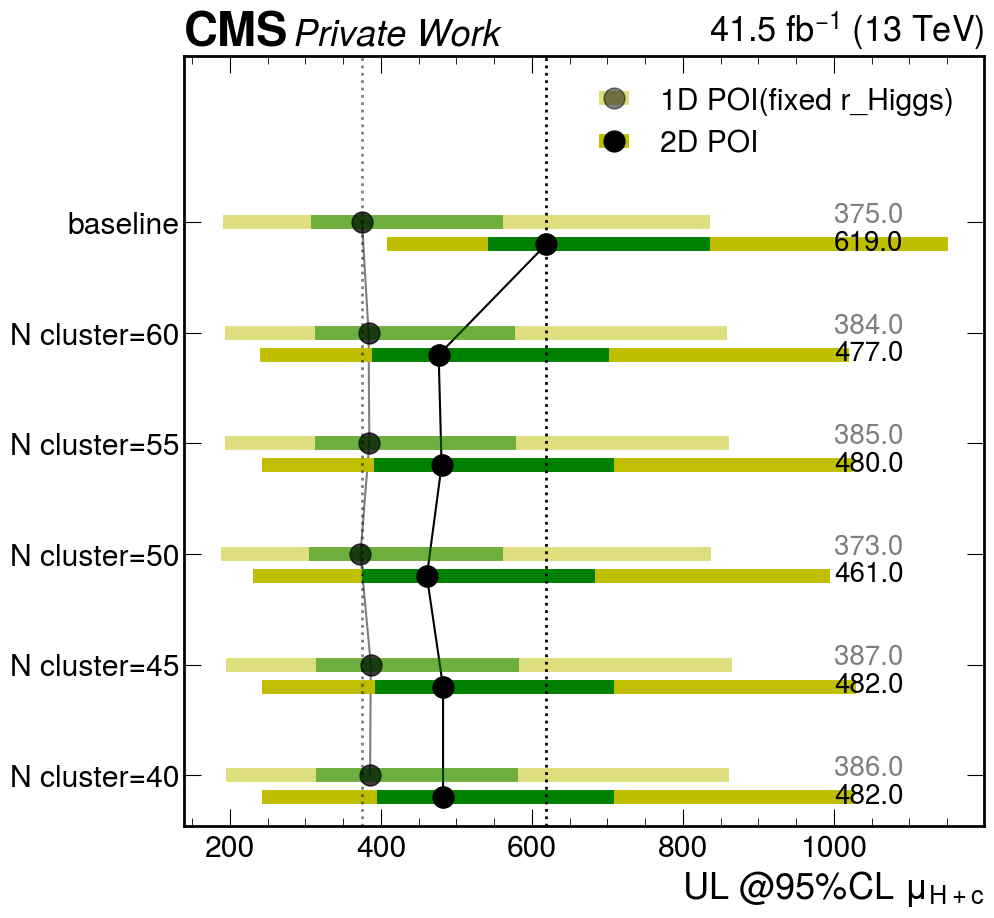

In [8]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
plt.style.use(hep.style.ROOT)
types=[".r_higgs","","1D.r_higgs","1D"]

bins={
    # "2018":
    # {
    #     "lumi":59.8,
    #     "SR2":[40,45,50,55,60],
    #     "SR":[25,30,35,40]
    # },
    "2017":
    {
        "lumi":41.5,
        "SR2":[40,45,50,55,60],
        # "SR":[25,30,35,40]
    },
    # "2016_postVFP":
    # {
    #     "lumi":16.8,
    #     "SR2":[35,40,45,50,55],
    #     "SR":[15,20,25,30,35]
    # }
    #  "2016_preVFP":
    # {
    #     "lumi":19.5,
    #     "SR2":[40,45,50,55,60],
    #     "SR":[25,30,35,40]
    # }
}
for year in bins.keys():
    for r in bins[year].keys():
        if r=="lumi" :continue
        limits={}
        for c in bins[year][r]:
            #[16,32,40,45,50]:
            limits[c]={}
            print(c)
            for t in types:
                f = uproot.open(f"../card_maker/cards/{year}_0608_clus_bin{c}_{r}_{year}/higgsCombinehc_emu_all_13TeV{t}.AsymptoticLimits.mH125.root")
        #         campaign="0607_off" if c=="2017" else "0507_splitJEC_noneg"
        #         if c!="Run2":f=uproot.open(f"../card_maker/cards/{c}_{campaign}_{c}/higgsCombinehc_emu_all_13TeV{t}.AsymptoticLimits.mH125.root")
        #         else:f=uproot.open(f"../card_maker/cards/higgsCombine0507_splitJEC_noneg_hc_emu_all_13TeV{t}.AsymptoticLimits.mH125.root")
                limits[c][t] = f["limit"]["limit"].array()
        limits["baseline"]={}
        for t in types:
            f = uproot.open(f"../card_maker/cards/2017_0507_splitJEC_noneg_2017/higgsCombinehc_emu_1_13TeV{t}.AsymptoticLimits.mH125.root")
            limits["baseline"][t] = f["limit"]["limit"].array()
        fig,ax=plt.subplots()
        
        fig.subplots_adjust(left=0.1)
        
        ax.errorbar([limits[cat]["1D"][2] for cat in limits.keys()],[i for i in range(len(limits.keys()))],
                     xerr = [[limits[cat]["1D"][2]-limits[cat]["1D"][0] for cat in limits.keys()],[limits[cat]["1D"][4]-limits[cat]["1D"][2] for cat in limits.keys()]],
                     fmt ='o',markerfacecolor='k',ecolor='y',markeredgecolor='k',lw=10,markersize=15,label="1D POI(fixed r_Higgs)",alpha=0.5)
        ax.plot([limits[cat]["1D"][2] for cat in limits.keys()],[i for i in range(len(limits.keys()))],
                     color='k',marker='o',markersize=15,alpha=0.5)
        ax.plot([limits[cat][""][2] for cat in limits.keys()],[i-0.2 for i in range(len(limits.keys()))],
                     color='k',marker='o',markersize=15)
        ax.errorbar( [limits[cat]["1D"][2] for cat in limits.keys()],[i for i in range(len(limits.keys()))],
                    xerr = [[limits[cat]["1D"][1]-limits[cat]["1D"][0] for cat in limits.keys()],[limits[cat]["1D"][3]-limits[cat]["1D"][2] for cat in limits.keys()]],
                     fmt ='o',ecolor='g',markeredgecolor='k',lw=10,markersize=0,alpha=0.5)
        ax.errorbar([limits[cat][""][2] for cat in limits.keys()],[i-0.2 for i in range(len(limits.keys()))],
                     xerr = [[limits[cat][""][2]-limits[cat][""][0] for cat in limits.keys()],[limits[cat][""][4]-limits[cat][""][2] for cat in limits.keys()]],
                     fmt ='o',markerfacecolor='k',markeredgecolor='k',ecolor='y',lw=10,label="2D POI",markersize=15)
        ax.errorbar( [limits[cat][""][2] for cat in limits.keys()],[i-0.2 for i in range(len(limits.keys()))],
                    xerr = [[limits[cat][""][1]-limits[cat][""][0] for cat in limits.keys()],[limits[cat][""][3]-limits[cat][""][2] for cat in limits.keys()]],
                     fmt ='o',ecolor='g',lw=10,markersize=0)
        
        # for ax.text()
        maxs=ax.get_xticklabels()[-2]
        print(maxs)
        for i,n in enumerate(limits.keys()):
        #     print(limits[n]["1D"][2])
            ax.text(ax.get_xticklabels()[-2].get_position()[0],i,str(round(limits[n]["1D"][2],0)),fontsize=20,alpha=0.5)
            ax.text(ax.get_xticklabels()[-2].get_position()[0],i-0.25,str(round(limits[n][""][2],0)),fontsize=20)
        #     ax.text(1300,i,str(round(limits[n]["1D"][2],0)),fontsize=20,alpha=0.5)
        #     ax.text(1300,i-0.25,str(round(limits[n][""][2],0)),fontsize=20)
        
        ax.set_yticklabels([f"N cluster={cat}" for cat in list(limits.keys()) if cat!="baseline"]+["baseline"])
        # ax.set_yticklabels(["","SR $m_{\\ell\\ell}<76GeV$","","+$m_{\\ell\\ell}\geq76GeV$","","+$m_{\\ell\\ell}\geq76GeV$+topCR","","+$m_{\\ell\\ell}\geq76GeV$+topCR loose mll"])
        import matplotlib.ticker as ticker
        ax.yaxis.set_minor_locator(ticker.NullLocator())
        ax.yaxis.set_major_locator(ticker.FixedLocator(np.arange(0,len(limits),1)))
        ax.set_xlabel("UL @95%CL $\\mu_{H+c}$")
        ax.legend()
        ax.set_ylim(top=len(limits)+0.5)
        ax.axvline(limits['baseline']["1D"][2],color='k',lw=2,alpha=0.5,ls=":",label="baseline (1 POI)")
        ax.axvline(limits['baseline'][""][2],color='k',lw=2,ls=":",label="baseline (2 POI)")
        # plt.axvline(x = 7, color = 'b', label = 'axvline - full height')
        
        fig.savefig(f"../card_maker/result_cluster_{year}_{r}_LM_rhc_old.pdf")

In [5]:
781/793

0.9848675914249685

/tmp/ipykernel_5198/2884192767.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f"N cluster={cat}" for cat in list(limits.keys()) if cat!="baseline"]+["baseline"])


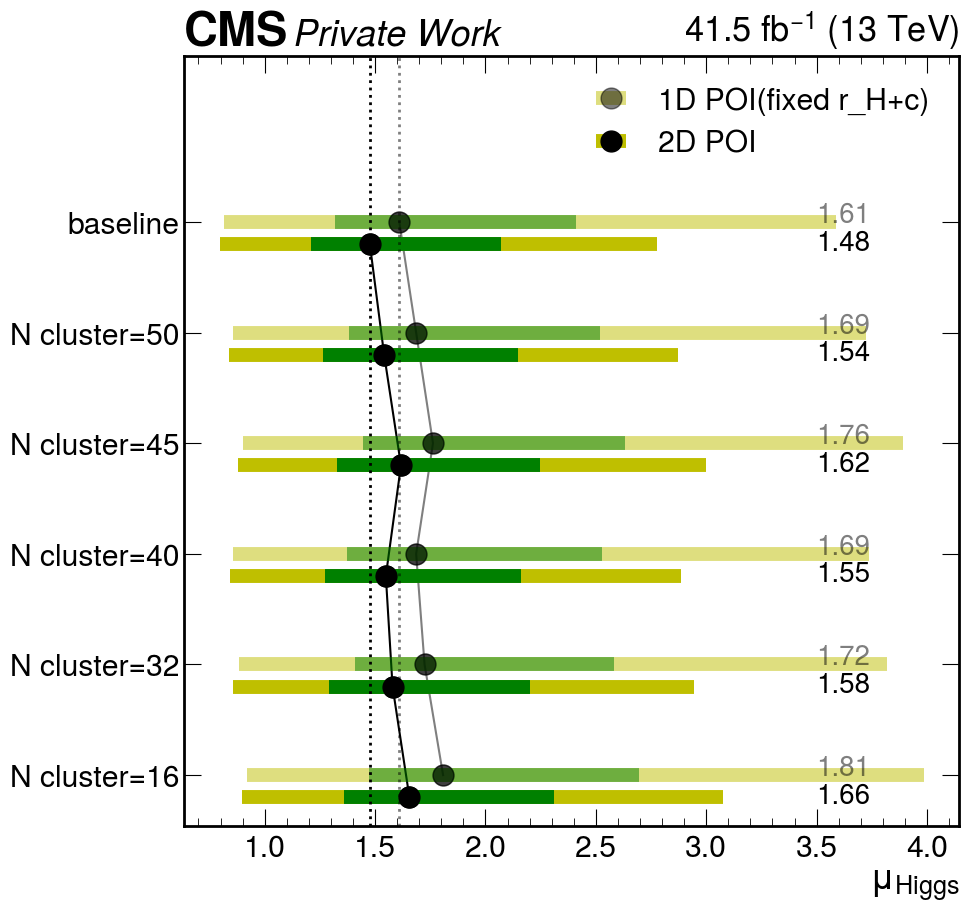

In [23]:
fig,ax=plt.subplots()
hep.cms.label(
        "Private Work",
        data=True,
        lumi=41.5,
#         com=config["com"],
        loc=0,
        ax=ax,
    )
ax.errorbar([limits[cat]["1D.r_higgs"][2] for cat in limits.keys()],[i for i in range(len(limits.keys()))],
             xerr = [[limits[cat]["1D.r_higgs"][2]-limits[cat]["1D.r_higgs"][0] for cat in limits.keys()],[limits[cat]["1D.r_higgs"][4]-limits[cat]["1D.r_higgs"][2] for cat in limits.keys()]],
             fmt ='o',markerfacecolor='k',ecolor='y',markeredgecolor='k',lw=10,markersize=15,label="1D POI(fixed r_H+c)",alpha=0.5)
ax.plot([limits[cat]["1D.r_higgs"][2] for cat in limits.keys()],[i for i in range(len(limits.keys()))],
             color='k',marker='o',markersize=15,alpha=0.5)
ax.plot([limits[cat][".r_higgs"][2] for cat in limits.keys()],[i-0.2 for i in range(len(limits.keys()))],
             color='k',marker='o',markersize=15)
ax.errorbar( [limits[cat]["1D.r_higgs"][2] for cat in limits.keys()],[i for i in range(len(limits.keys()))],
            xerr = [[limits[cat]["1D.r_higgs"][1]-limits[cat]["1D.r_higgs"][0] for cat in limits.keys()],[limits[cat]["1D.r_higgs"][3]-limits[cat]["1D.r_higgs"][2] for cat in limits.keys()]],
             fmt ='o',ecolor='g',markeredgecolor='k',lw=10,markersize=0,alpha=0.5)
ax.errorbar([limits[cat][".r_higgs"][2] for cat in limits.keys()],[i-0.2 for i in range(len(limits.keys()))],
             xerr = [[limits[cat][".r_higgs"][2]-limits[cat][".r_higgs"][0] for cat in limits.keys()],[limits[cat][".r_higgs"][4]-limits[cat][".r_higgs"][2] for cat in limits.keys()]],
             fmt ='o',markerfacecolor='k',markeredgecolor='k',ecolor='y',lw=10,label="2D POI",markersize=15)
ax.errorbar( [limits[cat][".r_higgs"][2] for cat in limits.keys()],[i-0.2 for i in range(len(limits.keys()))],
            xerr = [[limits[cat][".r_higgs"][1]-limits[cat][".r_higgs"][0] for cat in limits.keys()],[limits[cat][".r_higgs"][3]-limits[cat][".r_higgs"][2] for cat in limits.keys()]],
             fmt ='o',ecolor='g',lw=10,markersize=0)

# for ax.text()
for i,n in enumerate(limits.keys()):
#     print(limits[n]["1D.r_higgs"][2])
    ax.text(3.5,i,str(round(limits[n]["1D.r_higgs"][2],2)),fontsize=20,alpha=0.5)
    ax.text(3.5,i-0.25,str(round(limits[n][".r_higgs"][2],2)),fontsize=20)
ax.set_yticklabels([f"N cluster={cat}" for cat in list(limits.keys()) if cat!="baseline"]+["baseline"])
# ax.set_yticklabels([".r_higgs","SR $m_{\\ell\\ell}<76GeV$",".r_higgs","+$m_{\\ell\\ell}\geq76GeV$",".r_higgs","+$m_{\\ell\\ell}\geq76GeV$+topCR",".r_higgs","+$m_{\\ell\\ell}\geq76GeV$+topCR loose mll"])
import matplotlib.ticker as ticker
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.yaxis.set_major_locator(ticker.FixedLocator(np.arange(0,len(limits),1)))
ax.set_xlabel("$\\mu_{Higgs}$")
ax.legend()
ax.set_ylim(top=len(limits)+0.5)
ax.axvline(limits['baseline']["1D.r_higgs"][2],color='k',lw=2,alpha=0.5,ls=":",label="baseline (1 POI)")
ax.axvline(limits['baseline'][".r_higgs"][2],color='k',lw=2,ls=":",label="baseline (2 POI)")
# plt.axvline(x = 7, color = 'b', label = 'axvline - full height')

fig.savefig("../card_maker/result_cluster_SR2_LM_rhiggs.pdf")

## limit plot

In [4]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
plt.style.use(hep.style.ROOT)
types=["1D",""]#"_13TeV.r_higgs","_13TeV","1D_13TeV1D.r_higgs","1D_13TeV1D"]
years=["run2","2016_preVFP","2016_postVFP","2017","2018"]
# years=["run2"]
# ["2016_preVFP","2016_postVFP","2017","2018","Run2"]x

limits={}
for year in years:    
    limits[year]={}
    for t in types:
        f = uproot.open(f"../card_maker/cards/{year}_updated_{year}/higgsCombinehc_emu_all{t}_13TeV.AsymptoticLimits.mH125.root")
        #higgsCombinehc_emu_all{t}.AsymptoticLimits.mH125.root")
        limits[year][t] = f["limit"]["limit"].array()
    

In [7]:
import pandas as pd

for c in years:
    df = pd.DataFrame(limits[c])
    # print(c,df.round({'1D_13TeV1D.r_higgs': 2, '_13TeV.r_higgs': 2,"_13TeV":0,"1D_13TeV1D":0}))
    df

/tmp/ipykernel_40980/2647911344.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([cat.replace("_","\n") for cat in list(limits.keys())])


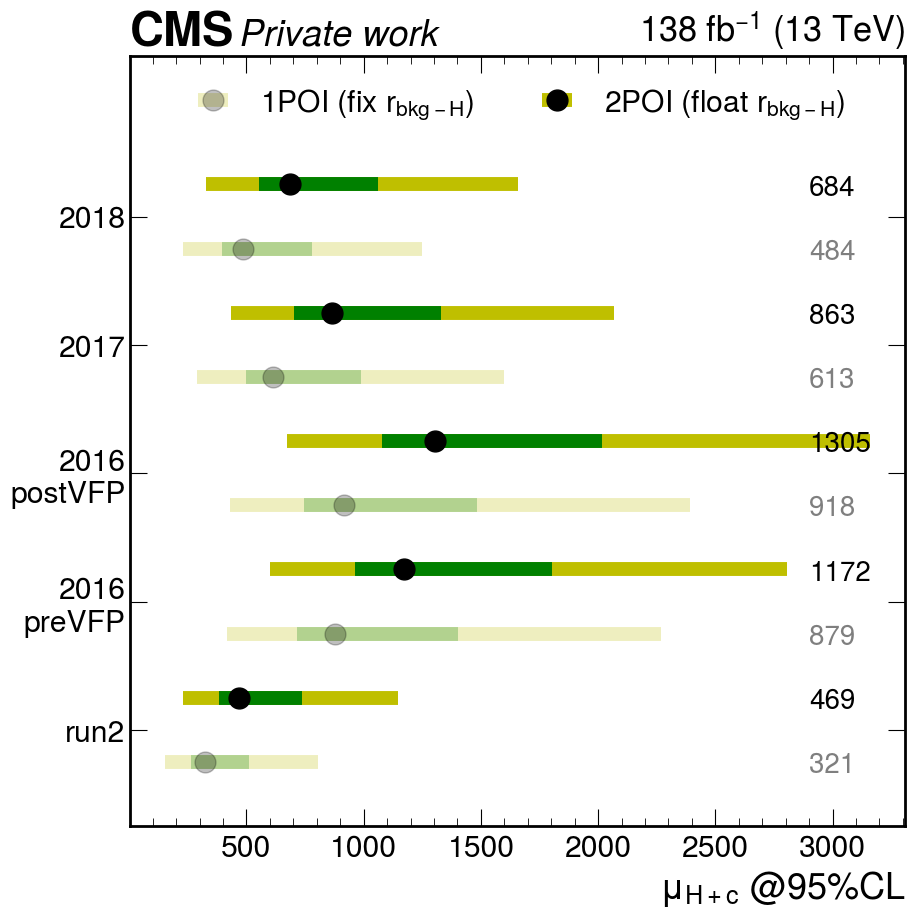

In [5]:
fig,ax=plt.subplots()#figsize=(6,3))
hep.cms.label(
        # "Preliminary",
        "Private work",
        data=True,
        lumi=138,
#         com=config["com"],
        loc=0,
        ax=ax,
    )
types=[".r_higgs","","1D.r_higgs","1D"]
# for c in ["2016_preVFP","2016_postVFP","2017","2018","run2"]:
ax.errorbar([limits[cat]["1D"][2] for cat in limits.keys()],[i+0.5 for i in range(len(limits.keys()))],
             xerr = [[limits[cat]["1D"][2]-limits[cat]["1D"][0] for cat in limits.keys()],[limits[cat]["1D"][4]-limits[cat]["1D"][2] for cat in limits.keys()]],
             fmt ='o',markerfacecolor='k',ecolor='y',markeredgecolor='k',lw=10,markersize=15,alpha=0.25,label="1POI (fix $r_{bkg-H}$)")
ax.errorbar( [limits[cat]["1D"][2] for cat in limits.keys()],[i+0.5 for i in range(len(limits.keys()))],
            xerr = [[limits[cat]["1D"][1]-limits[cat]["1D"][0] for cat in limits.keys()],[limits[cat]["1D"][3]-limits[cat]["1D"][2] for cat in limits.keys()]],
             fmt ='o',ecolor='g',markeredgecolor='k',lw=10,markersize=0,alpha=0.25)
ax.errorbar([limits[cat][""][2] for cat in limits.keys()],[i+1 for i in range(len(limits.keys()))],
             xerr = [[limits[cat][""][2]-limits[cat][""][0] for cat in limits.keys()],[limits[cat][""][4]-limits[cat][""][2] for cat in limits.keys()]],
             fmt ='o',markerfacecolor='k',markeredgecolor='k',ecolor='y',lw=10,markersize=15,label="2POI (float $r_{bkg-H}$)")
ax.errorbar( [limits[cat][""][2] for cat in limits.keys()],[i+1 for i in range(len(limits.keys()))],
            xerr = [[limits[cat][""][1]-limits[cat][""][0] for cat in limits.keys()],[limits[cat][""][3]-limits[cat][""][2] for cat in limits.keys()]],
             fmt ='o',ecolor='g',lw=10,markersize=0)
ax.set_yticklabels([cat.replace("_","\n") for cat in list(limits.keys())])
for i,n in enumerate(limits.keys()):
# #     print(limits[n]["1D.r_higgs"][2])
    ax.text(2900,i+0.42,str(round(limits[n]["1D"][2])),fontsize=20,alpha=0.5)
    ax.text(2900,i+0.92,str(round(limits[n][""][2])),fontsize=20)
import matplotlib.ticker as ticker
ax.yaxis.set_minor_locator(ticker.NullLocator())
# ax.yaxis.set_major_locator(ticker.FixedLocator([0.5,1.5]))
ax.yaxis.set_major_locator(ticker.FixedLocator([0.75, 1.75, 2.75,3.75, 4.75]))
# ax.text(1000,0.4,str(round(limits['run2']["1D"][2],1)),fontsize=20)
# ax.text(1000,1.4,str(round(limits['run2'][""][2],1)),fontsize=20)
ax.set_xlabel("$\\mu_{H+c}$ @95%CL")
handles,labels=ax.get_legend_handles_labels()
 # bbox_to_anchor=(0.5,0),bbox_transform=fig.transFigure,
# ax.legend(handles=handles[:2],labels=labels[:2])
ax.legend( loc="upper center", handles=handles[:2],labels=labels[:2],ncols=2)

ax.set_ylim(0,6)
# ax.set_xlim(0,1300)

# ax.set_yticklabels(["1POI\n(fix $r_{bkg-Higgs}$)","2POI\n(float $r_{bkg-Higgs}$)"])
# ax.axhline(1.,color="black",ls=":")
# ax.set_ylim(top=4.5)
fig.savefig("../card_maker/result_run2_combine_rhc_newCR.pdf")

{'2016_preVFP': {'1D': <Array [404, 560, 848, 1.35e+03, 2.18e+03] type='5 * float64'>,
  '': <Array [586, 788, ... 1.74e+03, 2.69e+03] type='5 * float64'>},
 '2016_postVFP': {'1D': <Array [461, 645, 984, 1.59e+03, 2.58e+03] type='5 * float64'>,
  '': <Array [659, 893, ... 2.01e+03, 3.16e+03] type='5 * float64'>},
 '2017': {'1D': <Array [265, 371, 561, 905, 1.46e+03] type='5 * float64'>,
  '': <Array [438, 594, 855, 1.31e+03, 2.03e+03] type='5 * float64'>},
 '2018': {'1D': <Array [230, 321, 482, 771, 1.23e+03] type='5 * float64'>,
  '': <Array [340, 472, 701, 1.09e+03, 1.7e+03] type='5 * float64'>},
 'run2': {'1D': <Array [158, 218, 326, 515, 817] type='5 * float64'>,
  '': <Array [228, 315, 471, 741, 1.15e+03] type='5 * float64'>}}

In [26]:
import numpy as np
for i,t in enumerate(types):
    collect["old"][t]=np.array(list(df[i]))

In [83]:
D1=["freeze_hc","freeze_pdf_scale","freeze_scale_FS","freeze_pdf_FS",""]
import uproot
for i in D1:
    
    file=uproot.open(f"../card_maker/cards/2018_cluster_2018/higgsCombinehc_emu_all1D_13TeV{i}.AsymptoticLimits.mH125.root")
    if i=="":i="float_all"
    collect[i]={}
    collect[i]["1POI_rHc"]=file["limit"]["limit"].array()

In [84]:
for i in D1:
    
    file=uproot.open(f"../card_maker/cards/2018_cluster_2018/higgsCombinehc_emu_all_13TeV{i}.AsymptoticLimits.mH125.root")
    if i=="":i="float_all"
    # collect[i]={}
    collect[i]["2POI_rHc"]=file["limit"]["limit"].array()

In [24]:
import uproot
import matplotlib.pyplot as plt
# syst=["rgx{prop.*}","rgx{CMS.*}","rgx{BR.*}","rgx{UEPS.*}","FS_hc","QCDscale_hc","rgx{PDFalphaS.*}","flavor_composition_ggH","rgx{lumi.*}","rgx{pdf.*}","pt_weight","rgx{scale.*}"]
syst=["rgx{CMS_scale.*}","rgx{CMS_res.*}","rgx{CMS_eff.*}","CMS_L1prefireweight_13TeV","CMS_pileup_2017_13TeV"]

newCR,updated=[],[]
name=[]
for s in syst:
    f=uproot.open(f"../card_maker/cards/2017_newCR_2017/higgsCombinehc_emu_2_13TeV{s}.AsymptoticLimits.mH125.root:limit")    
    f2=uproot.open(f"../card_maker/cards/2017_updated_2017/higgsCombinehc_emu_2_13TeV{s}.AsymptoticLimits.mH125.root:limit")    
    updated.append(f2["limit"].array()[2])
    name.append(s)
    newCR.append(f["limit"].array()[2])

[377.9296875, 377.9296875, 377.9296875, 377.9296875, 377.9296875]

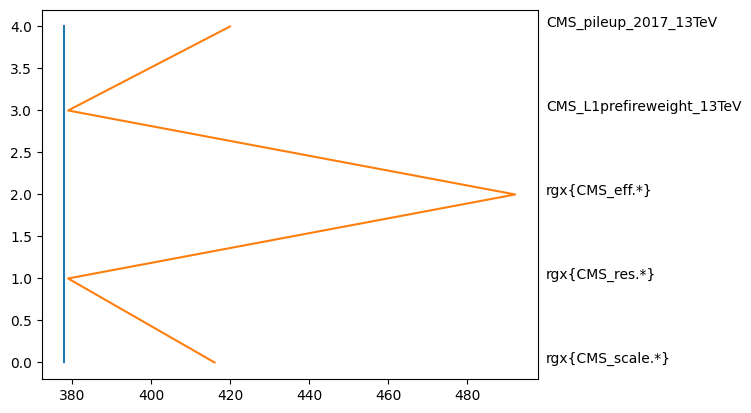

In [27]:
import numpy as np
fig, ax = plt.subplots()

ax.plot(updated,np.arange(0,len(syst),1),label="updated")
ax.plot(newCR,np.arange(0,len(syst),1),label="newCR")
# ax.set_yticklabels(name)
for i in range(len(syst)):
    ax.text(500,i,syst[i])
updated

In [1]:
import uproot
fu = uproot.open("../card_maker/shape/2018_SR2_LM_1D_template_BDT_SR2_LM_1D_updated.root")
import mplhep as hep
import matplotlib.pyplot as plt
# f,fu=f['hc_emu_2_13TeV'],fu['hc_emu_2_13TeV']
# f['hc_emu_2_13TeV'].keys()
for  i in fu.keys():
    if 'hc' not in i : continue
    if 'CMS_eff_c' in i or 'CMS_scale' in i :print(i)
    # if 'CMS_scale' in i :

hc_CMS_eff_c_DeepJetC_Interp_13TeVUp;1
hc_CMS_eff_c_DeepJetC_Interp_13TeVDown;1
hc_CMS_eff_c_DeepJetC_PSWeightISR_13TeVUp;1
hc_CMS_eff_c_DeepJetC_PSWeightISR_13TeVDown;1
hc_CMS_eff_c_DeepJetC_jesTotal_13TeVUp;1
hc_CMS_eff_c_DeepJetC_jesTotal_13TeVDown;1
hc_CMS_eff_c_DeepJetC_Stat_2018_13TeVUp;1
hc_CMS_eff_c_DeepJetC_Stat_2018_13TeVDown;1
hc_CMS_eff_c_DeepJetC_PSWeightFSR_13TeVUp;1
hc_CMS_eff_c_DeepJetC_PSWeightFSR_13TeVDown;1
hc_CMS_eff_c_DeepJetC_XSec_BRUnc_WJets_c_13TeVUp;1
hc_CMS_eff_c_DeepJetC_XSec_BRUnc_WJets_c_13TeVDown;1
hc_CMS_eff_c_DeepJetC_XSec_BRUnc_DYJets_b_13TeVUp;1
hc_CMS_eff_c_DeepJetC_XSec_BRUnc_DYJets_b_13TeVDown;1
hc_CMS_eff_c_DeepJetC_XSec_BRUnc_DYJets_c_13TeVUp;1
hc_CMS_eff_c_DeepJetC_XSec_BRUnc_DYJets_c_13TeVDown;1
hc_CMS_eff_c_DeepJetC_Extrap_13TeVUp;1
hc_CMS_eff_c_DeepJetC_Extrap_13TeVDown;1
hc_CMS_eff_c_DeepJetC_LHEScaleWeight_muR_13TeVUp;1
hc_CMS_eff_c_DeepJetC_LHEScaleWeight_muR_13TeVDown;1
hc_CMS_eff_c_DeepJetC_PUWeight_13TeVUp;1
hc_CMS_eff_c_DeepJetC_PUWeigh

(0.0, 1000.0)

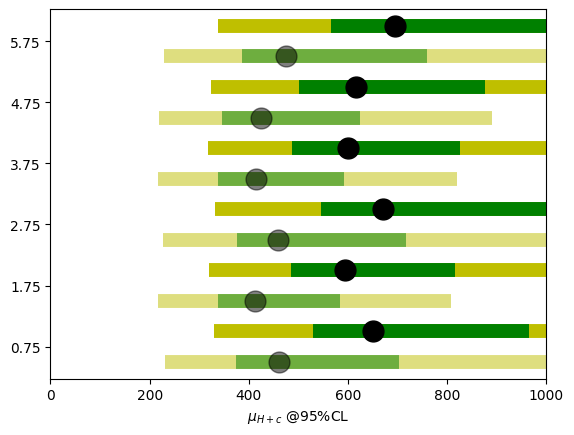

In [81]:
limits=collect
import matplotlib.pyplot as plt
fig,ax=plt.subplots()
# for cat in limits.keys():
#     print(limits[cat])

ax.errorbar([limits[cat]["1POI_rHc"][2] for cat in limits.keys()],[i+0.5 for i in range(len(limits.keys()))],
             xerr = [[limits[cat]["1POI_rHc"][2]-limits[cat]["1POI_rHc"][0] for cat in limits.keys()],[limits[cat]["1POI_rHc"][4]-limits[cat]["1POI_rHc"][2] for cat in limits.keys()]],
             fmt ='o',markerfacecolor='k',ecolor='y',markeredgecolor='k',lw=10,markersize=15,label="MC_cluster_UL17_v01)",alpha=0.5)
ax.errorbar( [limits[cat]["1POI_rHc"][2] for cat in limits.keys()],[i+0.5 for i in range(len(limits.keys()))],
            xerr = [[limits[cat]["1POI_rHc"][1]-limits[cat]["1POI_rHc"][0] for cat in limits.keys()],[limits[cat]["1POI_rHc"][3]-limits[cat]["1POI_rHc"][2] for cat in limits.keys()]],
             fmt ='o',ecolor='g',markeredgecolor='k',lw=10,markersize=0,alpha=0.5)
ax.errorbar([limits[cat]["2POI_rHc"][2] for cat in limits.keys()],[i+1. for i in range(len(limits.keys()))],
             xerr = [[limits[cat]["2POI_rHc"][2]-limits[cat]["2POI_rHc"][0] for cat in limits.keys()],[limits[cat]["2POI_rHc"][4]-limits[cat]["2POI_rHc"][2] for cat in limits.keys()]],
             fmt ='o',markerfacecolor='k',markeredgecolor='k',ecolor='y',lw=10,label="2D POI",markersize=15)
ax.errorbar( [limits[cat]["2POI_rHc"][2] for cat in limits.keys()],[i+1. for i in range(len(limits.keys()))],
            xerr = [[limits[cat]["2POI_rHc"][1]-limits[cat]["2POI_rHc"][0] for cat in limits.keys()],[limits[cat]["2POI_rHc"][3]-limits[cat]["2POI_rHc"][2] for cat in limits.keys()]],
             fmt ='o',ecolor='g',lw=10,markersize=0)
import matplotlib.ticker as ticker
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.yaxis.set_major_locator(ticker.FixedLocator([0.75,1.75,2.75,3.75,4.75,5.75]))
# ax.text(1000,0.4,str(round(limits['run2']["1D_13TeV1D"][2],1)),fontsize=20)
ax.set_xlabel("$\\mu_{H+c}$ @95%CL")
# ax.legend()
# ax.set_ylim(0,2)
ax.set_xlim(0,1000)

[Text(0, 0.5, '1POI\n(fix $r_{bkg-Higgs}$)'),
 Text(0, 1.5, '2POI\n(float $r_{bkg-Higgs}$)')]

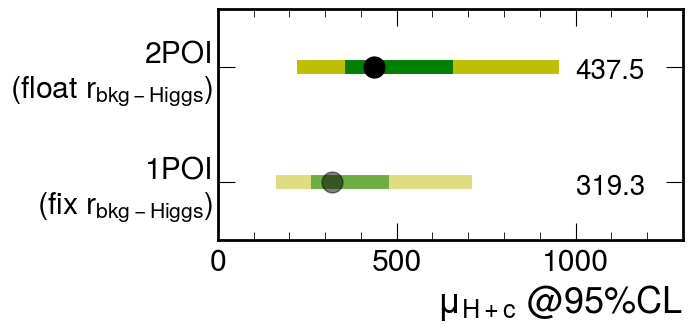

In [51]:
fig,ax=plt.subplots(figsize=(6,3))
# hep.cms.label(
#         "Preliminary",
#         data=True,
#         lumi=138,
# #         com=config["com"],
#         loc=0,
#         ax=ax,
#     )
# types=[".r_higgs","_13TeV","1D.r_higgs","1D"]
# for c in ["2016_preVFP","2016_postVFP","2017","2018","Run2"]:
ax.errorbar([limits[cat]["1D_13TeV1D"][2] for cat in limits.keys()],[i+0.5 for i in range(len(limits.keys()))],
             xerr = [[limits[cat]["1D_13TeV1D"][2]-limits[cat]["1D_13TeV1D"][0] for cat in limits.keys()],[limits[cat]["1D_13TeV1D"][4]-limits[cat]["1D_13TeV1D"][2] for cat in limits.keys()]],
             fmt ='o',markerfacecolor='k',ecolor='y',markeredgecolor='k',lw=10,markersize=15,label="MC_cluster_UL17_v01)",alpha=0.5)
ax.errorbar( [limits[cat]["1D_13TeV1D"][2] for cat in limits.keys()],[i+0.5 for i in range(len(limits.keys()))],
            xerr = [[limits[cat]["1D_13TeV1D"][1]-limits[cat]["1D_13TeV1D"][0] for cat in limits.keys()],[limits[cat]["1D_13TeV1D"][3]-limits[cat]["1D_13TeV1D"][2] for cat in limits.keys()]],
             fmt ='o',ecolor='g',markeredgecolor='k',lw=10,markersize=0,alpha=0.5)
ax.errorbar([limits[cat]["_13TeV"][2] for cat in limits.keys()],[i+1.5 for i in range(len(limits.keys()))],
             xerr = [[limits[cat]["_13TeV"][2]-limits[cat]["_13TeV"][0] for cat in limits.keys()],[limits[cat]["_13TeV"][4]-limits[cat]["_13TeV"][2] for cat in limits.keys()]],
             fmt ='o',markerfacecolor='k',markeredgecolor='k',ecolor='y',lw=10,label="2D POI",markersize=15)
ax.errorbar( [limits[cat]["_13TeV"][2] for cat in limits.keys()],[i+1.5 for i in range(len(limits.keys()))],
            xerr = [[limits[cat]["_13TeV"][1]-limits[cat]["_13TeV"][0] for cat in limits.keys()],[limits[cat]["_13TeV"][3]-limits[cat]["_13TeV"][2] for cat in limits.keys()]],
             fmt ='o',ecolor='g',lw=10,markersize=0)
# ax.set_yticklabels([cat.replace("_"," ") for cat in list(limits.keys())])
# for i,n in enumerate(limits.keys()):
#     print(limits[n]["1D.r_higgs"][2])
# ax.text(3.5,0,str(round(limits[n]["1D_13TeV1D"][2],2)),fontsize=20,alpha=0.5)
# ax.text(3.5,1-0.25,str(round(limits[n]["_13TeV"][2],2)),fontsize=20)
import matplotlib.ticker as ticker
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.yaxis.set_major_locator(ticker.FixedLocator([0.5,1.5]))
# ax.yaxis.set_major_locator(ticker.FixedLocator([0, 1, 2,3, 4]))
ax.text(1000,0.4,str(round(limits['run2']["1D_13TeV1D"][2],1)),fontsize=20)
ax.text(1000,1.4,str(round(limits['run2']["_13TeV"][2],1)),fontsize=20)
ax.set_xlabel("$\\mu_{H+c}$ @95%CL")
# ax.legend()
ax.set_ylim(0,2)
ax.set_xlim(0,1300)

ax.set_yticklabels(["1POI\n(fix $r_{bkg-Higgs}$)","2POI\n(float $r_{bkg-Higgs}$)"])
# ax.axhline(1.,color="black",ls=":")
# ax.set_ylim(top=4.5)
# fig.savefig("../card_maker/result_run2_combine_rhc.pdf")

/tmp/ipykernel_8777/3703506586.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([cat.replace("_"," ") for cat in list(limits.keys())])


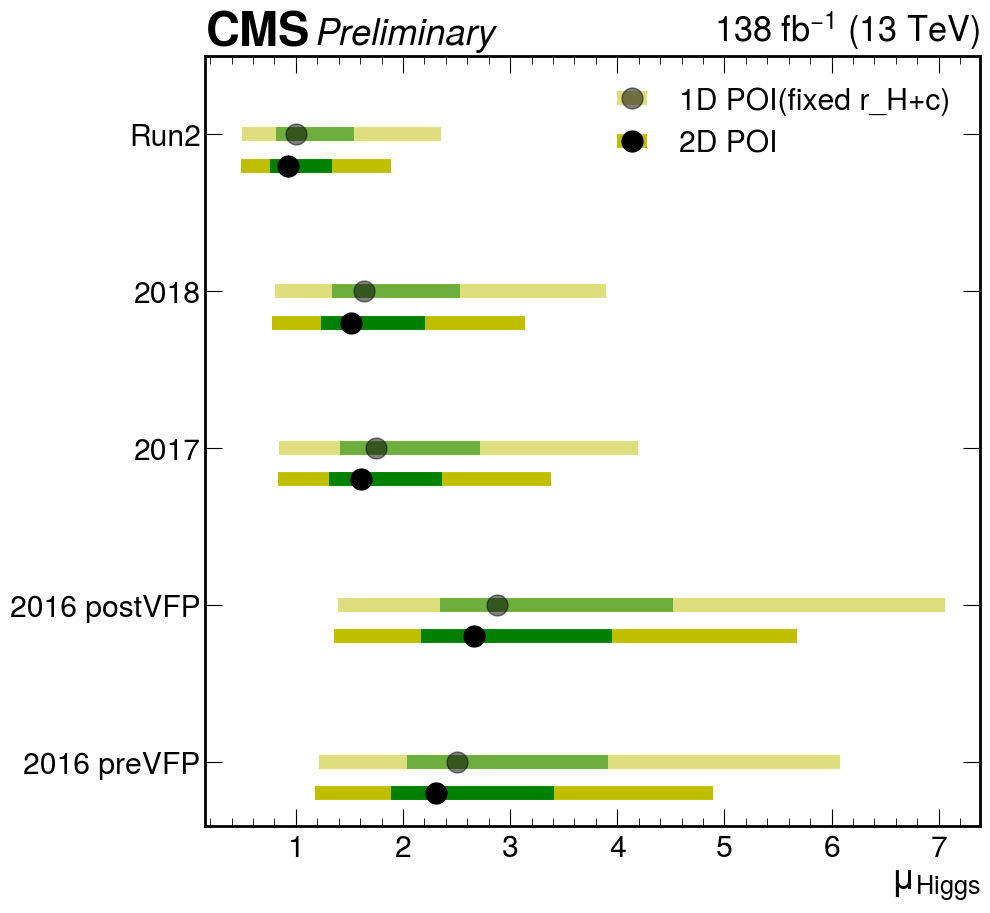

In [9]:
fig,ax=plt.subplots()
hep.cms.label(
        "Preliminary",
        data=True,
        lumi=138,
#         com=config["com"],
        loc=0,
        ax=ax,
    )
# types=[".r_higgs","","1D.r_higgs","1D"]
# for c in ["2016_preVFP","2016_postVFP","2017","2018","Run2"]:
ax.errorbar([limits[cat]["1D.r_higgs"][2] for cat in limits.keys()],[i for i in range(len(limits.keys()))],
             xerr = [[limits[cat]["1D.r_higgs"][2]-limits[cat]["1D.r_higgs"][0] for cat in limits.keys()],[limits[cat]["1D.r_higgs"][4]-limits[cat]["1D.r_higgs"][2] for cat in limits.keys()]],
             fmt ='o',markerfacecolor='k',ecolor='y',markeredgecolor='k',lw=10,markersize=15,label="1D POI(fixed r_H+c)",alpha=0.5)
ax.errorbar( [limits[cat]["1D.r_higgs"][2] for cat in limits.keys()],[i for i in range(len(limits.keys()))],
            xerr = [[limits[cat]["1D.r_higgs"][1]-limits[cat]["1D.r_higgs"][0] for cat in limits.keys()],[limits[cat]["1D.r_higgs"][3]-limits[cat]["1D.r_higgs"][2] for cat in limits.keys()]],
             fmt ='o',ecolor='g',markeredgecolor='k',lw=10,markersize=0,alpha=0.5)
ax.errorbar([limits[cat][".r_higgs"][2] for cat in limits.keys()],[i-0.2 for i in range(len(limits.keys()))],
             xerr = [[limits[cat][".r_higgs"][2]-limits[cat][".r_higgs"][0] for cat in limits.keys()],[limits[cat][".r_higgs"][4]-limits[cat][".r_higgs"][2] for cat in limits.keys()]],
             fmt ='o',markerfacecolor='k',markeredgecolor='k',ecolor='y',lw=10,label="2D POI",markersize=15)
ax.errorbar( [limits[cat][".r_higgs"][2] for cat in limits.keys()],[i-0.2 for i in range(len(limits.keys()))],
            xerr = [[limits[cat][".r_higgs"][1]-limits[cat][".r_higgs"][0] for cat in limits.keys()],[limits[cat][".r_higgs"][3]-limits[cat][".r_higgs"][2] for cat in limits.keys()]],
             fmt ='o',ecolor='g',lw=10,markersize=0)
ax.set_yticklabels([cat.replace("_"," ") for cat in list(limits.keys())])

import matplotlib.ticker as ticker
ax.yaxis.set_minor_locator(ticker.NullLocator())
ax.yaxis.set_major_locator(ticker.FixedLocator([0, 1, 2,3, 4]))
ax.set_xlabel("$\\mu_{Higgs}$")
ax.legend()
ax.set_ylim(top=4.5)
fig.savefig("../card_maker/result_run2_combine_rhiggs.pdf")

## fraction

[390.625, 396.484375, 390.625, 404.296875, 394.53125, 392.578125, 390.625, 392.578125, 402.34375, 412.109375, 406.25, 455.078125]
[3750.0, 3953.125, 3796.875, 3765.625, 3765.625, 3750.0, 3750.0, 3750.0, 3984.375, 4015.625, 4046.8749999999995, 4562.5]
[387.6953125, 394.53125, 388.671875, 402.34375, 392.578125, 387.6953125, 387.6953125, 387.6953125, 400.390625, 396.484375, 398.4375, 435.546875]
[367.1875, 375.9765625, 369.140625, 376.953125, 376.953125, 367.1875, 367.1875, 367.1875, 372.0703125, 372.0703125, 369.140625, 404.296875]
[366.2109375, 375.0, 369.140625, 375.0, 376.953125, 366.2109375, 366.2109375, 366.2109375, 371.09375, 371.09375, 369.140625, 400.390625]


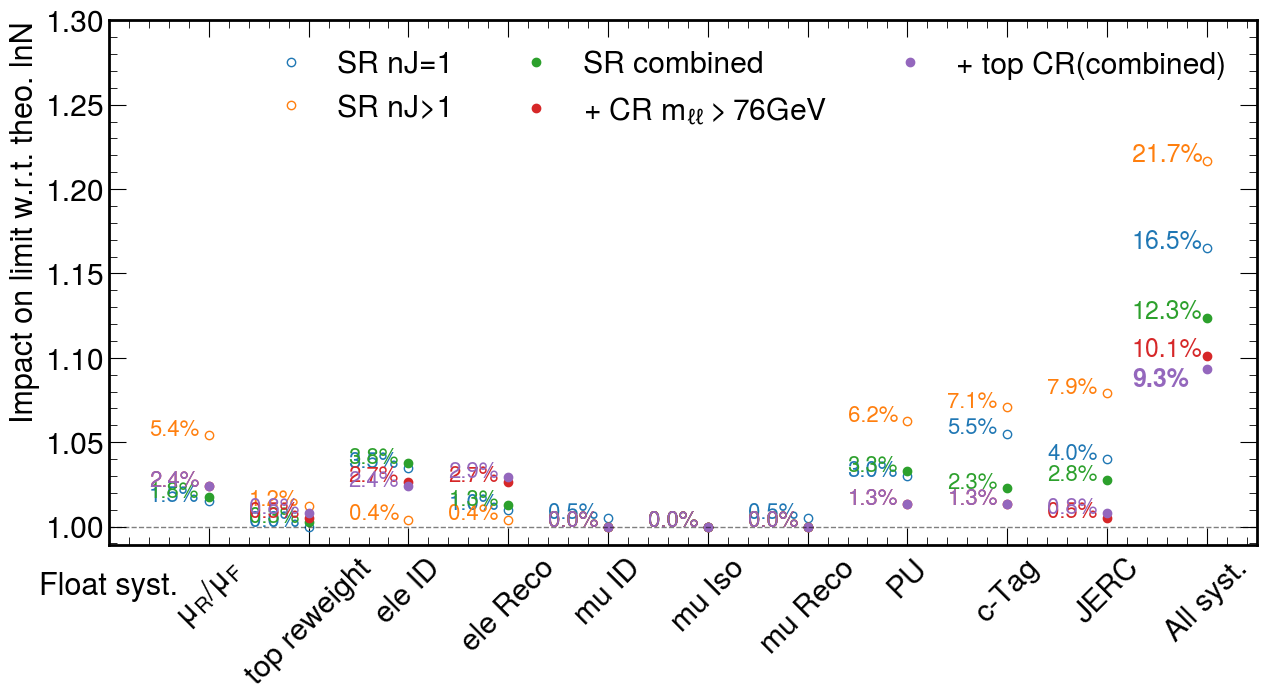

In [26]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
plt.style.use(hep.style.ROOT)
# from ..card_maker.plot_limit import getlimit
regs={"1":"SR nJ=1","2":"SR nJ>1","SR_LM_comb":"SR combined","SR":"+ CR $m_{\\ell\\ell}>76GeV$","all":"+ top CR(combined)"}
flist=np.array(["float_old","float_theoshape","float_ttbar","float_eleID","float_eleReco","float_muID","float_muIso","float_muReco","float_pu","float_ctag","float_JERC","freeze_st"])
# flist=np.array(["float_old","float_JERC","float_eleID","float_eleReco","float_muID","float_muIso","float_muReco","float_L1","float_pu","float_ttbar","float_theoshape","float_ctag","float_st",""])
# fig,ax=plt.subplots()
# medlim_new,error1_new,error2_new={},{},{}
med_collect={}
plt.figure(figsize=(15,8))

for reg in regs:
    med,errup,errdn=[],[],[]
    
    for unc in flist:
        f=uproot.open(f"../card_maker/cards/UL2017_0502_fixReco_2017/higgsCombinehc_emu_{reg}_13TeV{unc}.AsymptoticLimits.mH125.root")
        limit = f["limit"]["limit"].array()
        med.append(limit[2])
        errdn.append(limit[2]-limit[1])
        errup.append(limit[3]-limit[2])
#     print(reg,limit)
#     medlim_new[reg],error1_new[reg],error1_new[reg]=getlimit(limit)
    print(med)
    med=np.array(med)
    med_collect[reg]=(med/np.min(med))[1:]
#     print(med[0],np.min(med))
#     if flist!="float_old":  
    if "1"==reg or "2" == reg:plt.plot(np.arange(0,len(flist)-1,1),(med/np.min(med))[1:],label=regs[reg],marker='o',lw=0,mfc='none')
    else:plt.plot(np.arange(0,len(flist)-1,1),(med/np.min(med))[1:],label=regs[reg],marker='o',lw=0)
    
#     plt.errorbar(np.arange(0,len(flist),1),med/np.min(med),yerr=[errdn,errup],fmt='o')
#     ax.errorbar([medlim [reg] for cat in medlim.keys() if 'higgs' in cat],[1,2],
#              xerr = [[error2 [reg][0] for cat in medlim.keys()],[error2 [reg][1] for cat in medlim.keys()]],
#              fmt ='o',markerfacecolor='k',ecolor='y',lw=4,label="old")
# ax.errorbar( [medlim [reg] for cat in medlim.keys()],[1,2],
#             xerr = [[error1 [reg][0] for cat in medlim.keys()],[error1 [reg][1] for cat in medlim.keys()]],
#              fmt ='o',ecolor='g',lw=4,markersize=0)
# ax.errorbar([medlim_new [reg] for cat in medlim.keys()],[i-0.1 for i in range(len(medlim.keys()))],
#              xerr = [[error2_new [reg][0] for cat in medlim.keys()],[error2 [reg][1] for cat in medlim.keys()]],
#              fmt ='o',markerfacecolor='k',ecolor='y',lw=4,label="new(add SV)")
# ax.errorbar( [medlim_new [reg] for cat in medlim.keys()],[i-0.1 for i in range(len(medlim.keys()))],
#             xerr = [[error1_new [reg][0] for cat in medlim.keys()],[error1 [reg][1] for cat in medlim.keys()]],
#              fmt ='o',ecolor='g',lw=4,markersize=0)
flist[flist==""]="float all"
# ax.set_xticklabels(flist)
# ax.set_yticklabels(["","SR $m_{\\ell\\ell}<76GeV$","","+$m_{\\ell\\ell}\geq76GeV$","","+$m_{\\ell\\ell}\geq76GeV$+topCR","","+$m_{\\ell\\ell}\geq76GeV$+topCR loose mll"])
plt.legend(ncol=3)
color=['tab:blue','tab:orange','tab:green','tab:red',"tab:purple","tab:brown"]

for c,reg in enumerate(med_collect.keys()):
    
    for i in range(0,len(flist)-1):
#         print(med_collect[reg][i],reg,i)
#         if c==4:plt.text(i-0.7,med_collect[reg][i]-0.03,f"{round((med_collect[reg][i]-1.)*100,1)}%",color=color[c])
#         else: 
        if i == len(flist)-2:
            if c==4:plt.text(i-0.75,med_collect[reg][i]-0.01,f"{round((med_collect[reg][i]-1.)*100,1)}%",color=color[c],size=18,fontweight='bold')
            else:plt.text(i-0.75,med_collect[reg][i],f"{round((med_collect[reg][i]-1.)*100,1)}%",color=color[c],size=18)
        else:plt.text(i-0.6,med_collect[reg][i],f"{round((med_collect[reg][i]-1.)*100,1)}%",color=color[c],size=16)
        
# print(len(flist),np.arange(0,len(flist),1))
name_list=["",'$\\mu_R/\\mu_F$',"top reweight","ele ID","ele Reco","mu ID","mu Iso","mu Reco","PU","c-Tag","JERC","All syst."]
plt.xticks(np.arange(0,len(name_list),1)-1, name_list, rotation=45)
plt.ylim(top=1.3)
# plt.locator_params(axis='x', nbins=len(x)/2)
# plt.plot(x, y, 'g-', color='red')
plt.tight_layout(pad=4)
plt.subplots_adjust(bottom=0.15)
# mpl.magic()
plt.ylabel("Impact on limit w.r.t. theo. lnN",size=22)
# plt.xlabel("Float syst.")
plt.text(-1.7,0.96,"Float syst.",size=22)
plt.axhline(1.0,**{"linestyle": "--", "color": (0, 0, 0, 0.5), "linewidth": 1})
# plt.savefig("impact_asymptotic.png")

In [4]:
import uproot
import numpy as np
f=uproot.open("../card_maker/cards/2017_0608_clus_bin30_SR_2017/fitDiagnosticshc_emu_all_13TeV_twoPOI_mu1_.ToyFreq.root")
dir(f['covariance_fit_b'].axes[0])#.name
cov='covariance_fit_s'
labelx=np.array(f[cov].axes[0].labels())#,#f['covariance_fit_s'].values()
labely=np.flip(np.array(f[cov].axes[1].labels()))
idx_tt,idx_st=np.where(labelx=='r_hc'),np.where(labelx=='r_higgs')
idy_tt,idy_st=np.where(labely=='r_hc'),np.where(labely=='r_higgs')

# labelx[np.where(labelx=='CMS_SF_ttbar_emu_13TeV_2017')[0]]
# labelx
value=np.array(f[cov].values())
# value
import pandas as pd
df = pd.DataFrame(value, columns=labelx,index=labely)
print(value[idx_tt,idy_tt],value[idx_tt,idy_st],value[idx_st,idy_st],value[idx_st,idy_tt])

# df.style.background_gradient()
# value[25,26]

[[1.]] [[-0.62836079]] [[1.]] [[-0.62836079]]


In [ ]:
fig,ax= plt.subplots()
ax.plot([1,2,3,4],[mu1_old_tt[i*3+2] for i in range(4)],marker='o',label='old')
ax.plot([1,2,3,4],[mu1_new_tt[i*3+2] for i in range(4)],marker='o',label='new')
ax.set_xticklabels(["","SR $m_{\\ell\\ell}<76GeV$","","+$m_{\\ell\\ell}\geq76GeV$","","+$m_{\\ell\\ell}\geq76GeV$\n+topCR","","+$m_{\\ell\\ell}\geq76GeV$\n+topCR loose mll"])
ax.set_title("Uncertainty of signal strength")

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import uproot

# data from https://allisonhorst.github.io/palmerpenguins/

species = (
 "SR \n$m_{\\ell\\ell}<76GeV$ \n& nJ=1", "SR \n$m_{\\ell\\ell}<76GeV$ \n& nJ>1","CR\n $m_{\\ell\\ell}\geq76GeV$","CR\ntop")#,"top CR \n$m_{\\ell\\ell}$ inclusive"
# )
flist=["shape/SR2_LM_template_BDT_SR2_LM_0428.root","shape/SR_LM_template_BDT_SR_LM_0428.root","shape/SR_HM_template_BDT_SR_HM_0428.root","shape/top_CR_lowmT_template_mTh_0428.root"]
map_name={"data":'data_obs','Higgs (WW+ZZ)':'higgs',"TT":"ttbar","ST":'st',"Z+jets":'zjets','VV':'vv',"H+c":'hc'}
samples=['ttbar;1','st;1','zjets;1','vv;1','higgs;1','hc;1']
weight_counts={}
for s in samples:
    weight_counts[s]=[]
    for fl in flist:
        f=uproot.open(f'../card_maker/{fl}')
        weight_counts[s].append(np.sum(f[s].values()))
#         print(fl)
    
print(weight_counts)

{'ttbar;1': [14164.562890202864, 2462.214405622023, 20938.819928810964, 6388.76948386847], 'st;1': [1109.819009561187, 102.57362191621148, 1668.160104470475, 302.1993644151983], 'zjets;1': [64.88503001144464, 4.295889187903299, 9.330232876437563, 10.590260051956829], 'vv;1': [198.48933191481453, 11.632299819191246, 289.988959530103, 33.9355879912724], 'higgs;1': [73.94860634861679, 9.33044903179741, 15.287399637719812, 16.989282829347523], 'hc;1': [0.21247668591007335, 0.010616402227891808, 0.0006295296592709243, 0.011155065657990107]}


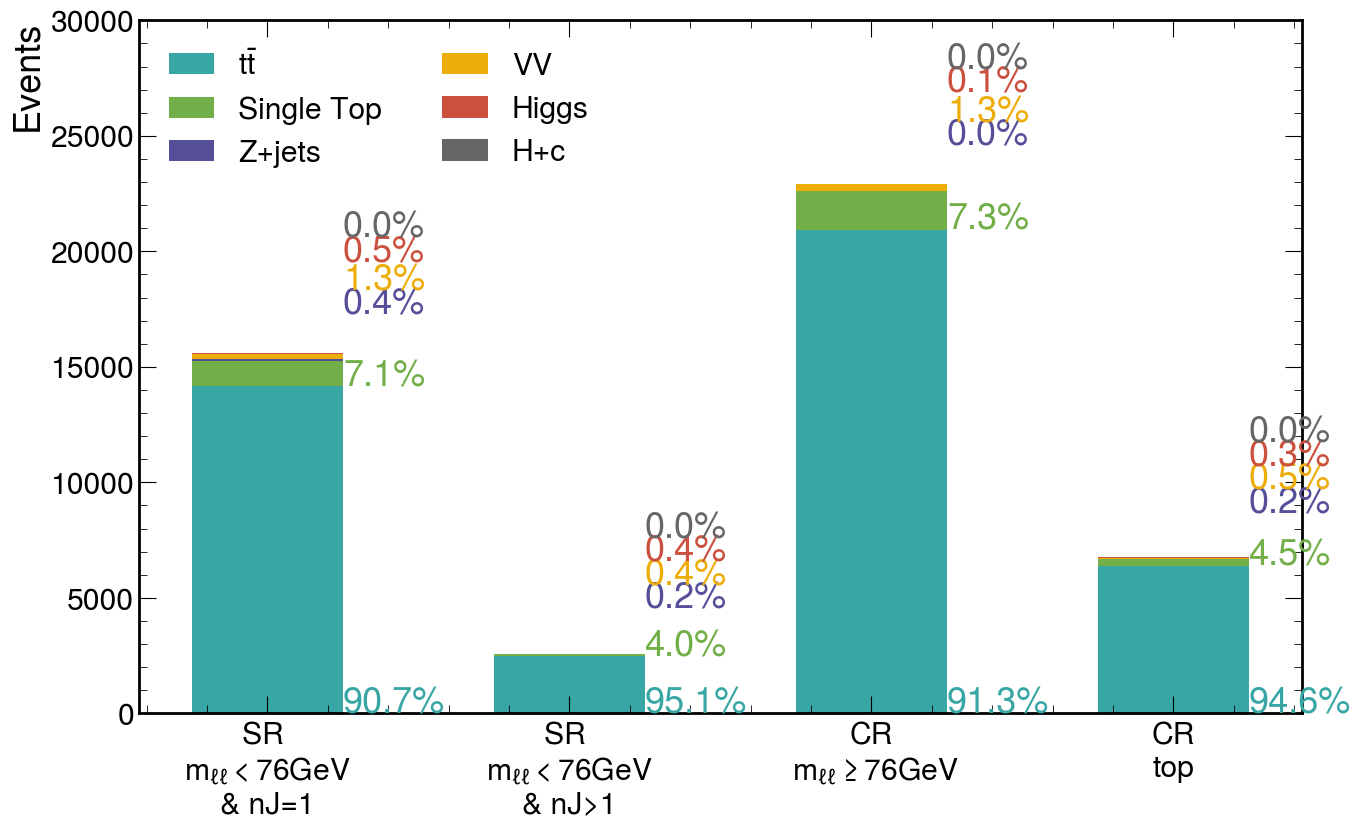

In [20]:
import mplhep as hep
plt.style.use(hep.style.ROOT)
width = 0.5

fig, ax = plt.subplots(figsize=(15,9))
bottom = np.zeros(len(species))
getsum=[weight_counts['ttbar;1'][i]+weight_counts['st;1'][i]+weight_counts['higgs;1'][i]+weight_counts['hc;1'][i]+weight_counts['vv;1'][i]+weight_counts['zjets;1'][i] for i in range(len(species))]
color=['tab:blue','tab:orange','tab:green','tab:red',"tab:purple","tab:brown"]
c=0
color_map={"$t\\bar{t}$":"#38A6A5","Single Top":"#73AF48","VV":"#EDAD08","Z+jets":"#554e99","Higgs":"#CC503E","H+c":"#666666"}
name_map={'ttbar;1':"$t\\bar{t}$","st;1":"Single Top","zjets;1":"Z+jets",'vv;1':"VV","higgs;1":"Higgs","hc;1":"H+c"}
for boolean, weight_count in weight_counts.items():
    ax.bar(species, weight_count, width, label=name_map[boolean], bottom=bottom,color=color_map[name_map[boolean]])
    
    
    
    for i in range(len(species)):
#         print((weight_counts[boolean][i]+bottom[i])/2)
        if c>1:ax.text(0.25+i, (bottom[i]+1000*c), f"{round(weight_counts[boolean][i]*100./getsum[i],1)}%",color=color_map[name_map[boolean]])
        else:ax.text(0.25+i, (bottom[i]+30), f"{round(weight_counts[boolean][i]*100./getsum[i],1)}%",color=color_map[name_map[boolean]])
    bottom += weight_count
    c=c+1
#     hep.cms.label(
#         "Private work(CMS data/simulation)", data=True, loc=0, ax=ax,fontsize=24
#     )
ax.legend(loc="upper left",ncols=2,)
# ax.set_title("background composition")
ax.set_ylabel("Events")
ax.set_ylim(0,30000)
# plt.show()\
plt.savefig("bkg_composition.pdf")

In [22]:
import uproot
collated=uproot.open("../card_maker/shape/2class_SR_LM_BDT_emu_0418_rebin.root")
collated['hc;1'].variances()

array([7.31085058e-09, 6.67074585e-09, 4.56209938e-09, 5.64266237e-09,
       6.41868715e-09, 6.00741258e-09, 4.66792002e-09, 4.18121380e-09,
       5.05068195e-09, 4.80977503e-09, 5.08641952e-09, 4.67210299e-09,
       5.81154218e-09, 5.36264073e-09, 5.48323737e-09, 5.59452328e-09,
       4.36543382e-09, 9.45104587e-09, 8.62139288e-09, 7.65072466e-09,
       8.87974847e-09, 7.00776007e-09, 1.19663139e-08, 1.35727606e-08,
       1.43109285e-08, 1.98371270e-08, 2.09617675e-08, 2.32555031e-08,
       3.69053313e-08, 1.11906642e-08])

In [2]:
from BTVNanoCommissioning.utils.xs_scaler import collate
from BTVNanoCommissioning.utils.plot_utils import load_coffea
import numpy as np
from BTVNanoCommissioning.helpers.xsection import xsection
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt, mplhep as hep
from BTVNanoCommissioning.utils.plot_utils import (
    isin_dict,
    check_config,
    load_coffea,
    load_default,
    rebin_and_xlabel,
    plotratio,
    errband_opts,
    autoranger,
)
import numpy as np

<Axes: >

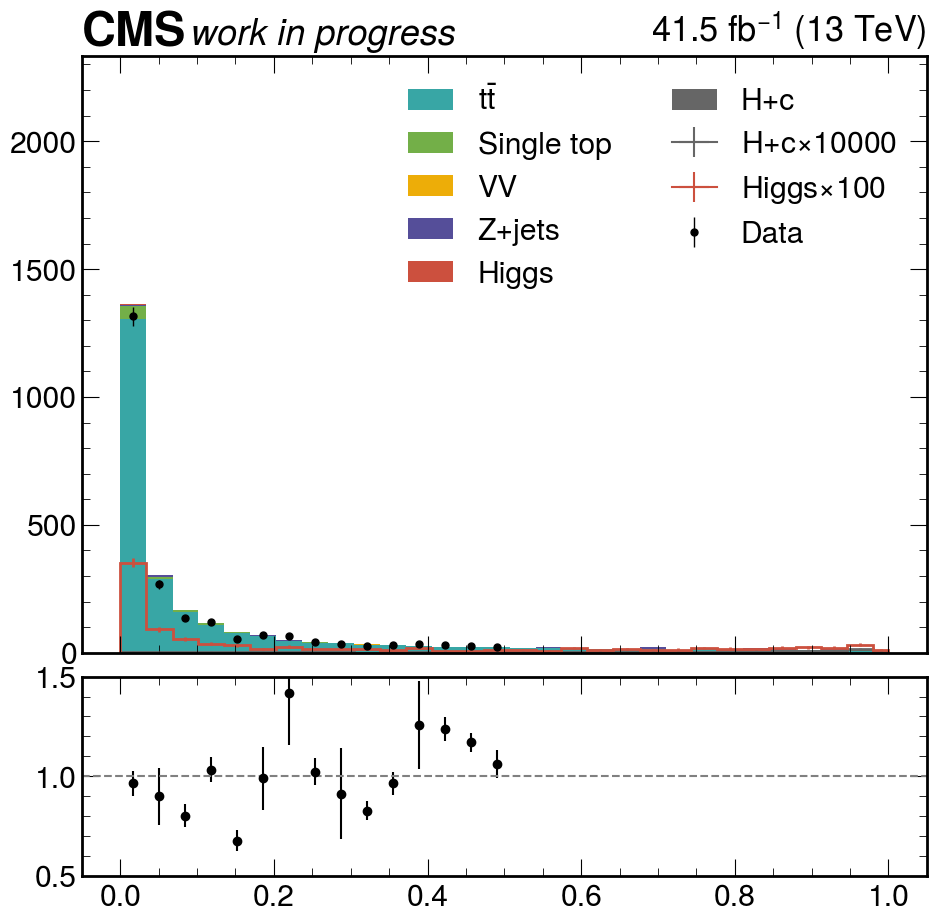

In [23]:
lumi=41500
fig, ((ax), (rax)) = plt.subplots(
            2, 1, gridspec_kw={"height_ratios": (3, 1)}, sharex=True
        )
plt.style.use(hep.style.ROOT)
fig.subplots_adjust(hspace=0.06, top=0.92, bottom=0.1, right=0.97)
hep.cms.label(
    "work in progress",
    data=True,
    lumi=lumi/ 1000.0,
    com="13",
    loc=0,
    ax=ax,
)
summc,summcvar=None,None
color_map={"ttbar;1":"#38A6A5","st;1":"#73AF48","vv;1":"#EDAD08","zjets;1":"#554e99","higgs;1":"#CC503E","Higgs (ZZ)":"#e17c05","hc;1":"#666666"}
for s in collated.keys():
    if "data" in s :continue
    if summc is None :
        summc=collated[s].values()
        summcvar=collated[s].variances()
    else:
        summc=summc+collated[s].values()
        summcvar=summcvar+collated[s].variances()
# # print(datavar,"MC:",np.sum(summc.values()),"data:",np.sum(collated['data'][datavar][axis].values()))
hep.histplot(
    [collated['ttbar;1'],collated['st;1'],collated['vv;1'],collated['zjets;1'],collated['higgs;1'],collated['hc;1']],
    stack=True,
    label=['$t\\bar{t}$','Single top','VV','Z+jets',"Higgs","H+c"],
    histtype="fill",
    yerr=True,
    color=["#38A6A5","#73AF48","#EDAD08","#554e99","#CC503E","#666666"],
    ax=ax,
    flow=None
)

hep.histplot(
    collated["hc;1"].values()*10000,
    collated['hc;1'].axes[0].edges(),
    label="H+c$\\times$10000",
    histtype="step",
    yerr=True,
    color=color_map["hc;1"],
    lw=2,
    ax=ax,
    flow=None
)
hep.histplot(
    collated["higgs;1"].values()*100,
    collated['hc;1'].axes[0].edges(),
    label="Higgs$\\times$100",
    histtype="step",
    yerr=True,
    color=color_map["higgs;1"],
    lw=2,
    ax=ax,flow=None
)

npdata=collated['data_obs;1'].values()

npdatavar=collated['data_obs;1'].variances()
npdata[-15:],npdatavar[-15:]=np.nan,np.nan
hep.histplot(
    npdata,
   collated['hc;1'].axes[0].edges(),
    histtype="errorbar",
    color="black",
    label="Data",
    yerr=True,
    ax=ax,flow=None
)
# plotratio(npdata, summc, ax=rax,data_is_np=True)
# center = (bin_bkg[:-1] + bin_bkg[1:]) / 2
rax.errorbar(
            collated['hc;1'].axes[0].centers(), 
            npdata/summc, 
            yerr=np.sqrt(summcvar**2/summc**2), 
            linestyle='None', 
            color='black', 
    #        color='tab:cyan', 
            marker='o', 
        )
ax.set_ylim(bottom=0.1)
rax.set_ylim(0.5,1.5)

ax.legend(ncols=2)
at = AnchoredText("",  frameon=False,loc=2)
ax.add_artist(at)
rax.axhline(y=1, color="gray", linestyle="--")
hep.mpl_magic(ax=ax)
# #     print(collated["data"][datavar][axis])

# rax.set_ylabel("Data/MC")
# if 'template_BDT' in datavar:rax.set_xlabel("BDT")
# else:rax.set_xlabel(train_collect[datavar][0])
# rax.set_ylim(0.5, 1.5)
# ax.set_xlabel(None)

# xmin, xmax = autoranger(collated["data"][datavar][axis] + summc)
# rax.set_xlim(xmin, xmax)
# # pvaleu=stats.ks_2samp(collated['data'][datavar][axis].values(), summc.values()).pvalue
# print(pvaleu)
# #     text = "GoF p-value:\n"+str(round(pvaleu,2))
# #     if var in trainvar_old:text=text+"\n("
# text="SR nJ>1"#texts[reg]
# ax.set_ylim(bottom=0.1)


# ax.legend(ncols=2)

# at = AnchoredText(text,  frameon=False,loc=2)
# ax.add_artist(at)

# hep.mpl_magic(ax=ax)

In [1]:
import uproot
medlimit=[]
for b in [10,20,30,40,45,50,55,60]:
    f=uproot.open(f"../card_maker/higgsCombinebin{b}_2class_2j_2017_hc_emu_5_13TeV.AsymptoticLimits.mH125.root")
    limit = f["limit"]["limit"].array()
    medlimit.append(limit[2])

# plt.plot([10,20,30,40,50,60],medlimit)
import numpy as np
plt.plot([10,20,30,40,45,50,55,60],medlimit/np.min(medlimit))
plt.title("SR nJ>1")
plt.ylabel('limit w.r.t. best choice')
plt.xlabel("# of bins")

In [ ]:
import uproot
medlimit=[]
for b in [10,20,30,40,45,50,55,60]:
    f=uproot.open(f"../card_maker/higgsCombinebin{b}_2class_2j_2017_hc_emu_3_13TeV.AsymptoticLimits.mH125.root")
    limit = f["limit"]["limit"].array()
    medlimit.append(limit[2])

import matplotlib.pyplot as plt
plt.plot( [10,20,30,40,45,50,55,60],medlimit/np.min(medlimit))
print(medlimit)
plt.title("SR nJ==1")
plt.ylabel('limit w.r.t. best choice')
plt.xlabel("# of bins")

In [ ]:
import uproot
medlimit=[]
import numpy as np
for b in [10,20,30,40,45,50,55,60]:
    f=uproot.open(f"../card_maker/higgsCombinebin{b}_2class_2j_2017_hc_emu_3_13TeV.AsymptoticLimits.mH125.root")
    limit = f["limit"]["limit"].array()
    medlimit.append(limit[2])

import matplotlib.pyplot as plt
plt.errorbar( [10,20,30,40,45,50,55,60],(medlimit/np.min(medlimit)),label="combine",fmt='o')

# plt.errorbar(  np.sort(np.array(list(set(params2[:,0])))),np.min(approx2)/approx2,fmt='o',label="approx")

sig=[
-1.9557083078325377e-05,-9.51606724015619e-05,-7.356280190151665e-05,-0.0001010919696966539,-0.00023443266707090515 
,-0.00018673305896754755,
-0.00012593720862241753,
-0.000633470075626974,
-0.00045648392017483275,
-7.484774107524572e-05 ,
-0.00022922216192000633]
# print(np.arange(10,61,5))
plt.errorbar(np.arange(10,61,5),np.min(sig)/sig,label='approx',fmt='o')

plt.title("SR nJ==1")
plt.ylabel('limit w.r.t. best choice')
plt.xlabel("# of bins")
# plt.legend()

In [28]:
import hist as Hist
categories = ["SR_LM","SR_SV","SR_HM","top_CR_lowmT","top_CR"]
region_axis = Hist.axis.StrCategory(categories, name="region")
syst_axis = Hist.axis.StrCategory([], name="syst", growth=True)
flav_axis = Hist.axis.IntCategory([0, 1, 4, 5, 6], name="flav", label="Genflavour")
lepflav_axis = Hist.axis.StrCategory(
    ["ee", "mumu", "emu"], name="lepflav", label="channel"
)
npv_axis= Hist.axis.Integer(0,100,name="npv",label='# of PVs')
nsv_axis= Hist.axis.Integer(0,20,name="nsv",label='# of SVs')
n_axis= Hist.axis.Integer(0,10,name="n",label='# of SVs')
pt_axis = Hist.axis.Regular(50,0,300, name="pt", label=" $p_{T}$ [GeV]")
eta_axis = Hist.axis.Regular(25,-2.5,2.5, name="eta", label=" $\eta$")
phi_axis = Hist.axis.Regular(30,-3,3, name="phi", label="$\phi$")
dphi_axis = Hist.axis.Regular(30,-0.5,0.5, name="dphi", label="$D\phi$")
mass_axis = Hist.axis.Regular(50,0,300, name="mass", label="$m$ [GeV]")
iso_axis = Hist.axis.Regular(30,0,0.15, name="iso", label="Rel Iso")
dxy_axis = Hist.axis.Regular(50,-0.05,0.05, name="dxy", label="$d_{xy}$")
dz_axis = Hist.axis.Regular(50,0,0.1, name="dz", label="$d_{z}$")
dr_axis = Hist.axis.Regular(40,0,0.4, name="dr", label="$\\Delta R$")
disc_axis=Hist.axis.Regular(40,0.2,1, name="discr", label="$\\Delta R$")
# kinematic variables
mt_axis = Hist.axis.Regular(30,0,300, name="mt", label=" $m_{T}$ [GeV]")
cat= {
           
            "npvs": Hist.Hist(lepflav_axis,region_axis,flav_axis,npv_axis,syst_axis,Hist.storage.Weight()),    
            "nsv": Hist.Hist(lepflav_axis,region_axis,flav_axis,nsv_axis,Hist.storage.Weight()),    
            "ll_mass":Hist.Hist(lepflav_axis,region_axis,flav_axis,mass_axis,Hist.storage.Weight()),
            "lep1_pfRelIso03_all":Hist.Hist(lepflav_axis,region_axis,flav_axis,iso_axis,Hist.storage.Weight()),
            "lep2_pfRelIso03_all":Hist.Hist(lepflav_axis,region_axis,flav_axis,iso_axis,Hist.storage.Weight()),
            "lep1_dxy":Hist.Hist(lepflav_axis,region_axis,flav_axis,dxy_axis,Hist.storage.Weight()),
            "lep2_dxy":Hist.Hist(lepflav_axis,region_axis,flav_axis,dxy_axis,Hist.storage.Weight()),
            "lep1_dz":Hist.Hist(lepflav_axis,region_axis,flav_axis,dz_axis,Hist.storage.Weight()),
            "lep2_dz":Hist.Hist(lepflav_axis,region_axis,flav_axis,dz_axis,Hist.storage.Weight()),
            "lep1_eta":Hist.Hist(lepflav_axis,region_axis,flav_axis,eta_axis,Hist.storage.Weight()),
            "lep2_eta":Hist.Hist(lepflav_axis,region_axis,flav_axis,eta_axis,Hist.storage.Weight()),
            "jetflav_eta":Hist.Hist(lepflav_axis,region_axis,flav_axis,eta_axis,Hist.storage.Weight()),
            "ll_eta":Hist.Hist(lepflav_axis,region_axis,flav_axis,eta_axis,Hist.storage.Weight()),
            "lep1_phi":Hist.Hist(lepflav_axis,region_axis,flav_axis,phi_axis,Hist.storage.Weight()),
            "lep2_phi":Hist.Hist(lepflav_axis,region_axis,flav_axis,phi_axis,Hist.storage.Weight()),
            "jetflav_phi":Hist.Hist(lepflav_axis,region_axis,flav_axis,phi_axis,Hist.storage.Weight()),
            "ll_phi":Hist.Hist(lepflav_axis,region_axis,flav_axis,phi_axis,Hist.storage.Weight()),
            "lep1_pt":Hist.Hist(lepflav_axis,region_axis,flav_axis,pt_axis,Hist.storage.Weight()),
            "lep2_pt":Hist.Hist(lepflav_axis,region_axis,flav_axis,pt_axis,Hist.storage.Weight()),
            "jetflav_pt":Hist.Hist(lepflav_axis,region_axis,flav_axis,pt_axis,Hist.storage.Weight()),
            "ll_pt":Hist.Hist(lepflav_axis,region_axis,flav_axis,pt_axis,Hist.storage.Weight()),
            "nj": Hist.Hist(lepflav_axis,region_axis,flav_axis,n_axis,Hist.storage.Weight()),
            "nele": Hist.Hist(lepflav_axis,region_axis,flav_axis,n_axis,Hist.storage.Weight()),
            "nmu": Hist.Hist(lepflav_axis,region_axis,flav_axis,n_axis,Hist.storage.Weight()),
            "njmet": Hist.Hist(lepflav_axis,region_axis,flav_axis,n_axis,Hist.storage.Weight()),
            "h_pt":Hist.Hist(lepflav_axis,region_axis,flav_axis,pt_axis,Hist.storage.Weight()),
            "MET_pt":Hist.Hist(lepflav_axis,region_axis,flav_axis,pt_axis,Hist.storage.Weight()),
            "MET_phi" : Hist.Hist(lepflav_axis,region_axis,flav_axis,phi_axis,Hist.storage.Weight()),
            "l1met_dphi" : Hist.Hist(lepflav_axis,region_axis,flav_axis,phi_axis,Hist.storage.Weight()),
            "l2met_dphi" : Hist.Hist(lepflav_axis,region_axis,flav_axis,phi_axis,Hist.storage.Weight()),
            "cW1_dphi" : Hist.Hist(lepflav_axis,region_axis,flav_axis,phi_axis,Hist.storage.Weight()),
            "lll1_dr" : Hist.Hist(lepflav_axis,region_axis,flav_axis,dr_axis,Hist.storage.Weight()),
            "lll2_dr" : Hist.Hist(lepflav_axis,region_axis,flav_axis,dr_axis,Hist.storage.Weight()),
            "llc_dr" : Hist.Hist(lepflav_axis,region_axis,flav_axis,dr_axis,Hist.storage.Weight()),
            "jetflav_btagDeepFlavCvL": Hist.Hist(lepflav_axis,region_axis,flav_axis,disc_axis,Hist.storage.Weight()),
            "jetflav_btagDeepFlavCvB": Hist.Hist(lepflav_axis,region_axis,flav_axis,disc_axis,Hist.storage.Weight()),
            "template_ll_mass":Hist.Hist(syst_axis,lepflav_axis,region_axis,flav_axis,mass_axis,Hist.storage.Weight()),
            "template_mTh":Hist.Hist(syst_axis,lepflav_axis,region_axis,flav_axis,mt_axis,Hist.storage.Weight()),
            "template_mT1":Hist.Hist(syst_axis,lepflav_axis,region_axis,flav_axis,mt_axis,Hist.storage.Weight()),
            "template_mT2":Hist.Hist(syst_axis,lepflav_axis,region_axis,flav_axis,mt_axis,Hist.storage.Weight()),
            "template_MET":Hist.Hist(syst_axis,lepflav_axis,region_axis,flav_axis,pt_axis,Hist.storage.Weight()),
            "template_jetpt":Hist.Hist(syst_axis,lepflav_axis,region_axis,flav_axis,pt_axis,Hist.storage.Weight()),
            "template_BDT":Hist.Hist(syst_axis,lepflav_axis,region_axis,flav_axis,disc_axis,Hist.storage.Weight()),
            # "array":{ch:{flav :{} for flav in ['emu']}for ch in categories}
            }
cat.keys()

dict_keys(['npvs', 'nsv', 'll_mass', 'lep1_pfRelIso03_all', 'lep2_pfRelIso03_all', 'lep1_dxy', 'lep2_dxy', 'lep1_dz', 'lep2_dz', 'lep1_eta', 'lep2_eta', 'jetflav_eta', 'll_eta', 'lep1_phi', 'lep2_phi', 'jetflav_phi', 'll_phi', 'lep1_pt', 'lep2_pt', 'jetflav_pt', 'll_pt', 'nj', 'nele', 'nmu', 'njmet', 'h_pt', 'MET_pt', 'MET_phi', 'l1met_dphi', 'l2met_dphi', 'cW1_dphi', 'lll1_dr', 'lll2_dr', 'llc_dr', 'jetflav_btagDeepFlavCvL', 'jetflav_btagDeepFlavCvB', 'template_ll_mass', 'template_mTh', 'template_mT1', 'template_mT2', 'template_MET', 'template_jetpt', 'template_BDT'])

In [ ]:
'cW1_dphi', 'lll1_dr', 'lll2_dr', 'llc_dr', ,    'template_BDT']

In [19]:
binning_SR2=[0.,0.034,0.068,0.101,0.135,0.169,0.203,0.237,0.27,0.304,0.338,0.372
,0.406,0.439,0.473,0.507,0.541,0.574,0.608,0.642,0.676,0.71,0.743,0.777
,0.811,0.845,0.879,0.912,0.946,0.98,1.,]
len(binning_SR2)

31

In [122]:
import uproot 
f=uproot.open("../card_maker/shape/top_CR_lowmT_emu_0403_new.root")
f['data_obs'].axes[0].edges()

array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140., 150., 160., 170., 180., 190., 200., 210.,
       220., 230., 240., 250., 260., 270., 280., 290., 300.])

In [104]:
from coffea.util import load
output = load("signal_nsv_v01/output.coffea")

[ErrorBarArtists(errorbar=<ErrorbarContainer object of 3 artists>)]

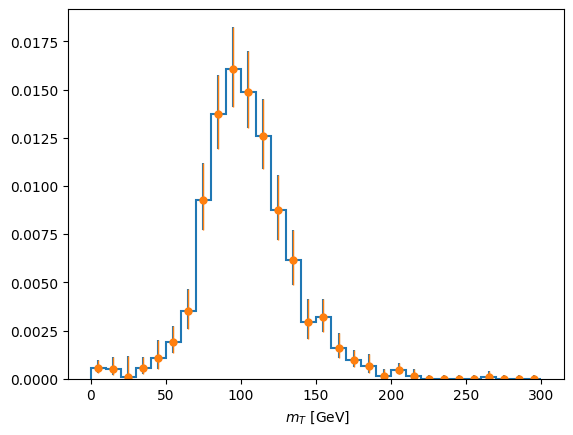

In [128]:
import mplhep as hep
# output['gchcWW2L2Nu_4f']['template_BDT_SR2_LM'][{'lepflav':'emu','region':'SR2_LM','flav':sum}].plot()
# hep.histplot(output['gchcWW2L2Nu_4f']['template_BDT_SR2_LM'][{'lepflav':'emu','region':'SR2_LM','flav':sum,'syst':sum}],density=True)
# # output['gchcWW2L2Nu_4f']['template_BDT_SR_HM'][{'lepflav':'emu','region':'SR_HM','flav':sum}].plot()
# # output['gchcWW2L2Nu_4f']['nj'][{'lepflav':'emu','region':'SR_LM','flav':sum}].plot()
# f['hc'].axes[0].edges()
hep.histplot(f['hc'],density=True)
hep.histplot(output['gchcWW2L2Nu_4f']['template_mTh'][{'lepflav':'emu','region':'top_CR_lowmT','flav':sum,'syst':'nominal'}],histtype='errorbar',density=True)

In [1]:

# for i in [ 'DeepJetC_LHEScaleWeight_muRDown', 'DeepJetC_PSWeightISRDown', 'PDFaS_weightUp', 'ele_IDUp', 'DeepJetC_XSec_BRUnc_WJets_cDown', 'scalevar_7ptDown', 'mu_IsoUp', 'aS_weightUp', 'ele_RecoUp', 'mu_RecoUp', 'DeepJetC_ExtrapDown', 'DeepJetC_InterpUp', 'mu_IDDown', 'scalevar_3ptUp', 'L1prefireweightDown', 'DeepJetC_PSWeightISRUp', 'DeepJetC_StatDown', 'DeepJetC_jesTotalUp', 'DeepJetC_StatUp', 'UEPS_ISRDown', 'UEPS_FSRUp', 'DeepJetC_PSWeightFSRUp', 'puweightUp', 'scalevar_3ptDown', 'mu_IDUp', 'DeepJetC_jerDown', 'PDFaS_weightDown', 'PDF_weightUp', 'puweightDown', 'DeepJetC_XSec_BRUnc_WJets_cUp', 'DeepJetC_XSec_BRUnc_DYJets_bUp', 'DeepJetC_ExtrapUp', 'DeepJetC_InterpDown', 'DeepJetC_LHEScaleWeight_muRUp', 'DeepJetC_PUWeightUp', 'DeepJetC_jerUp', 'DeepJetC_XSec_BRUnc_DYJets_cDown', 'DeepJetC_LHEScaleWeight_muFDown', 'DeepJetC_PUWeightDown', 'L1prefireweightUp', 'DeepJetC_XSec_BRUnc_DYJets_cUp', 'DeepJetC_PSWeightFSRDown', 'mu_IsoDown', 'ele_IDDown', 'DeepJetC_jesTotalDown', 'ele_RecoDown', 'mu_RecoDown', 'scalevar_7ptUp', 'UEPS_FSRDown', 'UEPS_ISRUp', 'DeepJetC_XSec_BRUnc_DYJets_bDown', 'aS_weightDown', 'DeepJetC_LHEScaleWeight_muFUp', 'PDF_weightDown', 'JESUp', 'JESDown', 'UESUp', 'UESDown', 'JERUp', 'JERDown']:
# #     if "DeepJet"  in i:continue
# #     if "ele" in i:continue
# #     if "PDF"  in i :continue
# #     if "mu_" not in i:continue
    
# #     if 'scalevar'  in i :continue
# #     if 'UE'  in i:continue
# #     if "JE"  in i :continue
# #     if "pu" not in i:continue
    
#     hep.histplot(output['gchcWW2L2Nu_4f']['template_BDT_SR2_LM'][{'lepflav':'emu','region':'SR2_LM','flav':sum,'syst':i}],label=i)
# plt.ylim(0,100)
# plt.legend()

## signal

In [5]:
import uproot
f_3FS=uproot.open("HPlusCharm_3FS_MuRFScaleDynX0p50_HToWW2L2Nu_M125_TuneCP5_13TeV_amcatnlo_pythia8.root")
f_4FS_FXFX=uproot.open("HPlusCharm_4FS_MuRFScaleDynX0p50_HToWW2L2Nu_M125_TuneCP5_13TeV_amcatnloFXFX_pythia8.root")
f_4FS=uproot.open("HPlusCharm_4FS_MuRFScaleDynX0p50_HToWW2L2Nu_M125_TuneCP5_13TeV_amcatnlo_pythia8.root")
f_4FS

In [6]:
arr_3FS=f_3FS["Events"].arrays(filter_name=["GenPart*","GenJet*","LHEPart_*"],entry_stop=5000)
arr_4FS=f_4FS["Events"].arrays(filter_name=["GenPart*","GenJet*","LHEPart_*"],entry_stop=5000)
arr_4FS_FXFX=f_4FS_FXFX["Events"].arrays(filter_name=["GenPart*","GenJet*","LHEPart_*"],entry_stop=5000)

In [7]:
fgg_4FS_FXFX=uproot.open("HPlusCharm_4FS_MuRFScaleDynX0p50_HToGG_M125_TuneCP5_13TeV_amcatnloFXFX_pythia8.root")
fgg_4FS=uproot.open("HPlusCharm_4FS_MuRFScaleDynX0p50_HToGG_M125_TuneCP5_13TeV_amcatnlo_pythia8.root")
fgg_3FS=uproot.open("HPlusCharm_3FS_MuRFScaleDynX0p50_HToGG_M125_TuneCP5_13TeV_amcatnlo_pythia8.root")

In [8]:
arrgg_3FS=fgg_3FS["Events"].arrays(filter_name=["GenPart*","GenJet*","LHEPart_*"],entry_stop=5000)
arrgg_4FS=fgg_4FS["Events"].arrays(filter_name=["GenPart*","GenJet*","LHEPart_*"],entry_stop=5000)
arrgg_4FS_FXFX=fgg_4FS_FXFX["Events"].arrays(filter_name=["GenPart*","GenJet*","LHEPart_*"],entry_stop=5000)

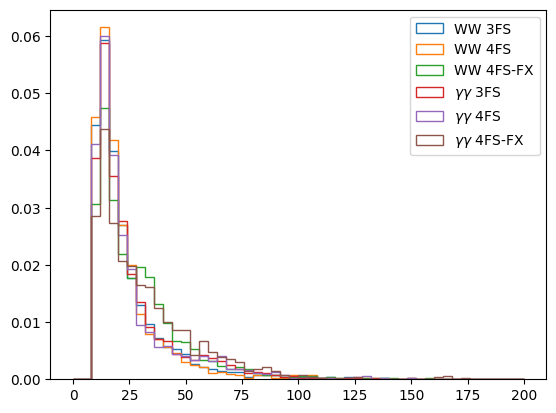

In [10]:
import matplotlib.pyplot as plt
import awkward as ak
plt.hist(ak.flatten(arr_3FS["GenJet_pt"][arr_3FS["GenJet_hadronFlavour"]==4],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='WW 3FS')
plt.hist(ak.flatten(arr_4FS["GenJet_pt"][arr_4FS["GenJet_hadronFlavour"]==4],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='WW 4FS')
plt.hist(ak.flatten(arr_4FS_FXFX["GenJet_pt"][arr_4FS_FXFX["GenJet_hadronFlavour"]==4],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='WW 4FS-FX')
plt.hist(ak.flatten(arrgg_3FS["GenJet_pt"][arrgg_3FS["GenJet_hadronFlavour"]==4],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='$\\gamma\\gamma$ 3FS')
plt.hist(ak.flatten(arrgg_4FS["GenJet_pt"][arrgg_4FS["GenJet_hadronFlavour"]==4],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='$\\gamma\\gamma$ 4FS')
plt.hist(ak.flatten(arrgg_4FS_FXFX["GenJet_pt"][arrgg_4FS_FXFX["GenJet_hadronFlavour"]==4],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='$\\gamma\\gamma$ 4FS-FX')
plt.legend()

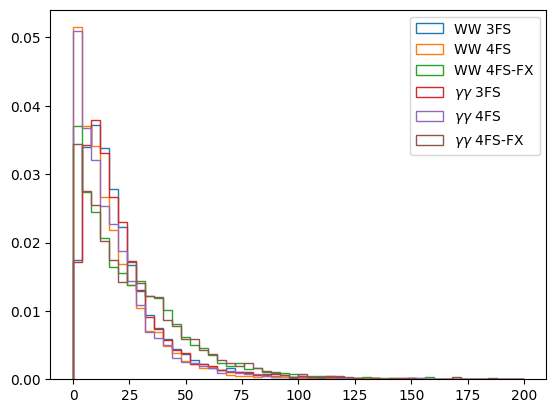

In [11]:
import matplotlib.pyplot as plt
import awkward as ak
plt.hist(ak.flatten(arr_3FS["GenPart_pt"][arr_3FS["GenPart_pdgId"]==25],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='WW 3FS')
plt.hist(ak.flatten(arr_4FS["GenPart_pt"][arr_4FS["GenPart_pdgId"]==25],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='WW 4FS')
plt.hist(ak.flatten(arr_4FS_FXFX["GenPart_pt"][arr_4FS_FXFX["GenPart_pdgId"]==25],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='WW 4FS-FX')
plt.hist(ak.flatten(arrgg_3FS["GenPart_pt"][arrgg_3FS["GenPart_pdgId"]==25],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='$\\gamma\\gamma$ 3FS')
plt.hist(ak.flatten(arrgg_4FS["GenPart_pt"][arrgg_4FS["GenPart_pdgId"]==25],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='$\\gamma\\gamma$ 4FS')
plt.hist(ak.flatten(arrgg_4FS_FXFX["GenPart_pt"][arrgg_4FS_FXFX["GenPart_pdgId"]==25],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='$\\gamma\\gamma$ 4FS-FX')
plt.legend()

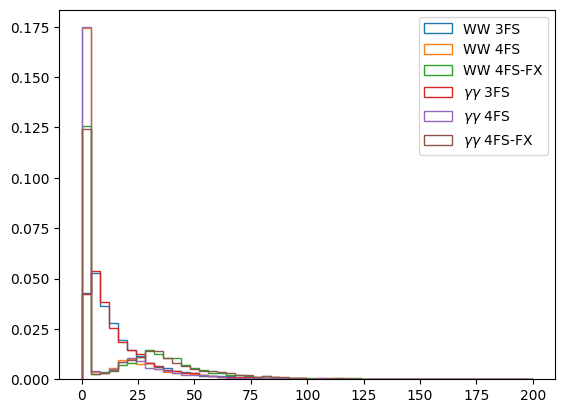

In [12]:
import matplotlib.pyplot as plt
import awkward as ak
plt.hist(ak.flatten(arr_3FS["LHEPart_pt"][arr_3FS["LHEPart_pdgId"]==25],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='WW 3FS')
plt.hist(ak.flatten(arr_4FS["LHEPart_pt"][arr_4FS["LHEPart_pdgId"]==25],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='WW 4FS')
plt.hist(ak.flatten(arr_4FS_FXFX["LHEPart_pt"][arr_4FS_FXFX["LHEPart_pdgId"]==25],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='WW 4FS-FX')
plt.hist(ak.flatten(arrgg_3FS["LHEPart_pt"][arrgg_3FS["LHEPart_pdgId"]==25],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='$\\gamma\\gamma$ 3FS')
plt.hist(ak.flatten(arrgg_4FS["LHEPart_pt"][arrgg_4FS["LHEPart_pdgId"]==25],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='$\\gamma\\gamma$ 4FS')
plt.hist(ak.flatten(arrgg_4FS_FXFX["LHEPart_pt"][arrgg_4FS_FXFX["LHEPart_pdgId"]==25],axis=-1),range=(0,200),bins=50,histtype='step',density=True,label='$\\gamma\\gamma$ 4FS-FX')
plt.legend()

## check shape

In [20]:
import uproot
shapes={ "SR2_LM_1D":"inputhc_emu_2_13TeV.root","SR2_LM":"inputhc_emu_3_13TeV.root"}

# shapes={"SR2_LM_1D":"inputhc_emu_2_13TeV.root", "HM_CR":"inputhc_emu_6_13TeV.root","SR_LM_1D":"inputhc_emu_5_13TeV.root","top_CR":"inputhc_emu_4_13TeV.root","SR2_LM":"inputhc_emu_3_13TeV.root","SR_LM":"inputhc_emu_1_13TeV.root"}
color_map={"ttbar":"#38A6A5","st":"#73AF48","vv":"#EDAD08","zjets":"#554e99","higgs":"#666666","hc":"#CC503E"}
name_map={"ttbar":"$t\\bar{t}$","st":"Single top","vv":"Diboson","zjets":"Z+jets","higgs":"bkg-H","hc":"H+c"}
reg={'top_CR':['top CR',"$m_T^{\\ell\\ell}$"],
     'HM_CR':['high $m_{\\ell\\ell}$ CR',"BDT(H+c,Bkg)"],
     'SR_LM':['nJet$>$1 SR',"clusters"],
     'SR2_LM':['nJet$=$1 SR',"clusters"],
     'SR_LM_1D':['nJet$>$1 SR',"BDT(H+c,Bkg)"],
     'SR2_LM_1D':['nJet$=$1 SR',"BDT(H+c,Bkg)"]}
# prefit=uproot.open("cards/run2_newCR_run2/fitDiagnosticshc_emu_all1D_13TeV_mu1_.preFit.root")
lumis={"2016_preVFP":19.5,"2016_postVFP":16.8,"2017":41.5,"2018":58.8}
opts = {
            "hatch": "////",
            "facecolor": "none",
            "lw": 0,
            "color": "k",
            "alpha": 0.4,
        }
syst={

            "facecolor": "k",
            "lw": 2,
            "color": "k",
            "alpha": 0.2,
        }
other={"linestyle": "--", "color": (0, 0, 0, 0.5), "linewidth": 1}

In [3]:
import uproot

import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use(hep.style.ROOT)
from BTVNanoCommissioning.utils.xs_scaler import collate
from BTVNanoCommissioning.utils.plot_utils import load_coffea
import numpy as np
from BTVNanoCommissioning.helpers.xsection import xsection
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt, mplhep as hep
%load_ext autoreload
%autoreload 2
from BTVNanoCommissioning.utils.plot_utils import (
    isin_dict,
    check_config,
    load_coffea,
    load_default,
    rebin_and_xlabel,
    plotratio,
    errband_opts,
    autoranger,
    rebin_hist
)
import numpy as np

45 45
[0.00555403 0.01072766 0.01184813 0.0164827  0.01936198 0.01786696
 0.02392927 0.02097115 0.02754199 0.02508205 0.02497284 0.02552717
 0.02729505 0.02840799 0.03811621 0.02865045 0.03021515 0.03053498
 0.03049731 0.04455366 0.03293625 0.04507408 0.04603594 0.03416251
 0.06175859 0.0346054  0.03499792 0.05335191 0.03591457 0.03779143
 0.03608655 0.07454992 0.03566424 0.03772268 0.05010704 0.06087426
 0.0346662  0.04228812 0.05383955 0.03240486 0.0317046  0.03258077
 0.03027837 0.0578698  0.16866237]
55 55
[0.01886987 0.01578802 0.01335902 0.02726756 0.01329159 0.01262376
 0.02653619 0.01289618 0.01249178 0.0189054  0.01620977 0.02635546
 0.01411242 0.0271643  0.02608974 0.01834997 0.03729961 0.02546374
 0.02401932 0.06616074 0.0234517  0.02184419 0.02946365 0.02349496
 0.03884333 0.02637851 0.03961766 0.02760448 0.02842781 0.0354025
 0.03917612 0.04585317 0.03058957 0.02698742 0.05074267 0.04028166
 0.02541566 0.07103337 0.04771421 0.03158511 0.05071084 0.04382323
 0.02866631 0.04

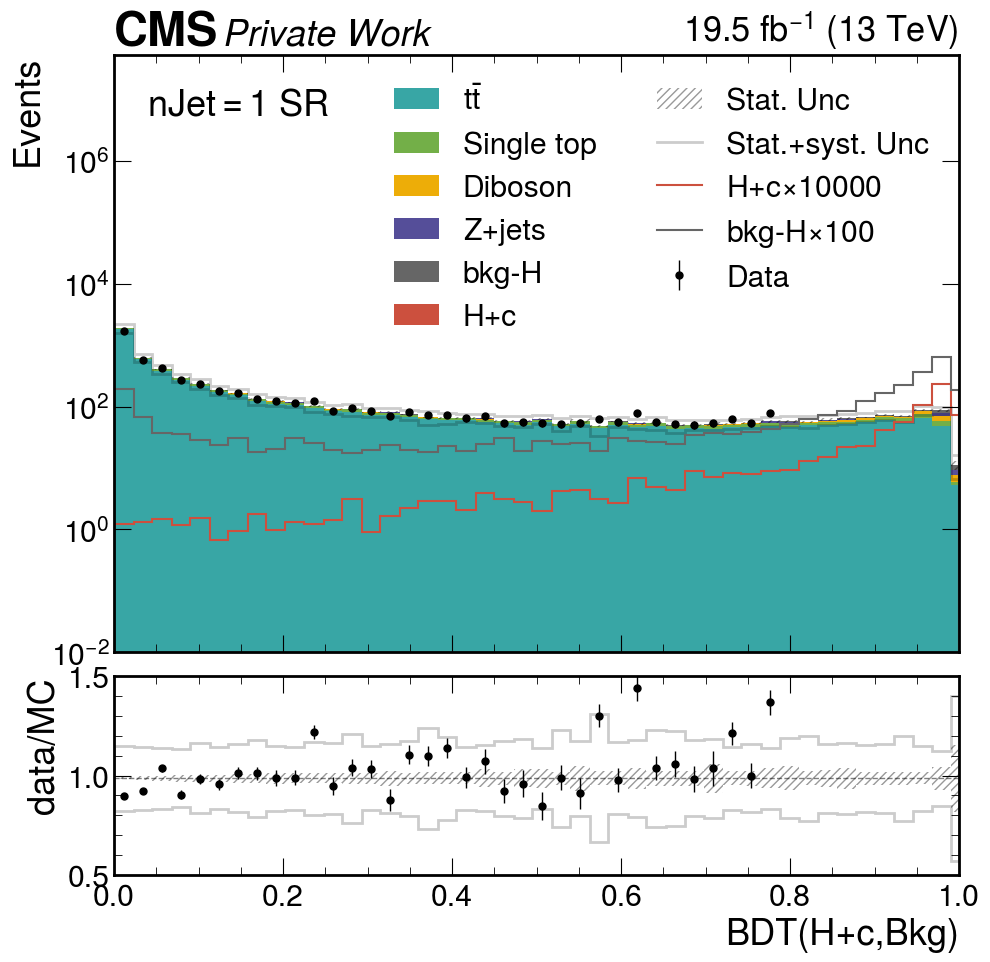

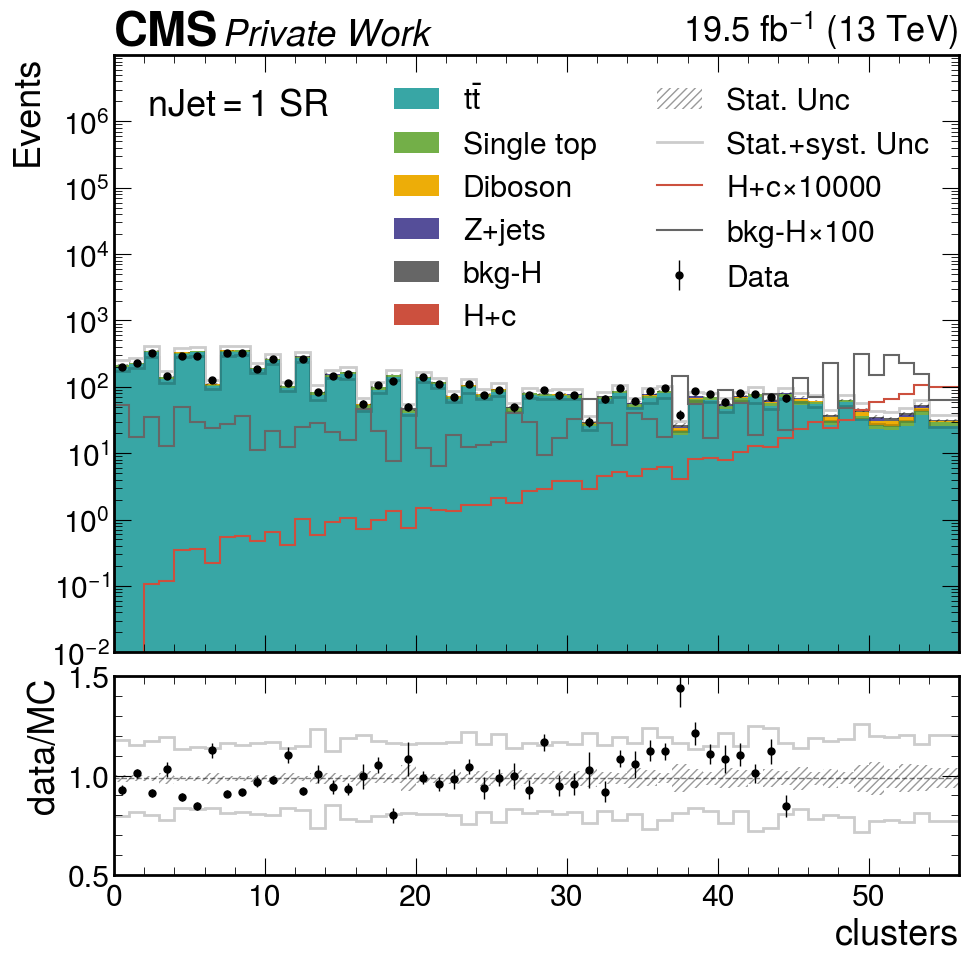

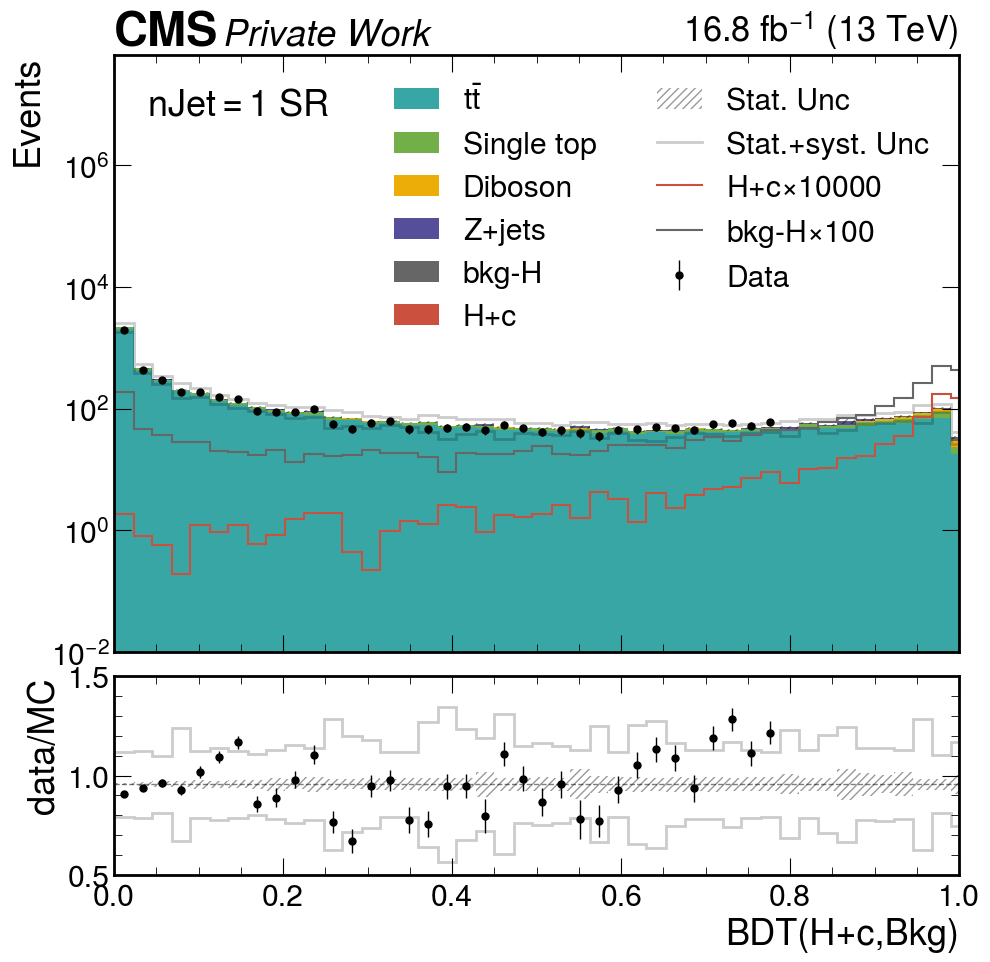

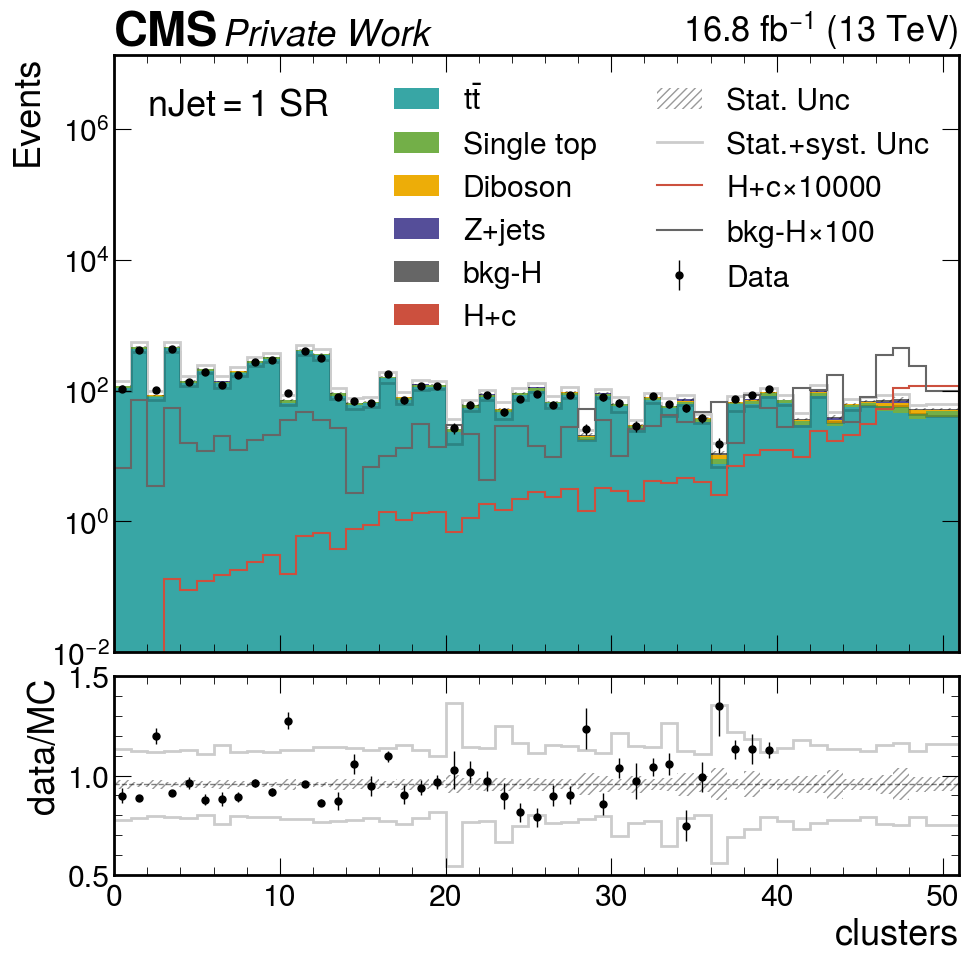

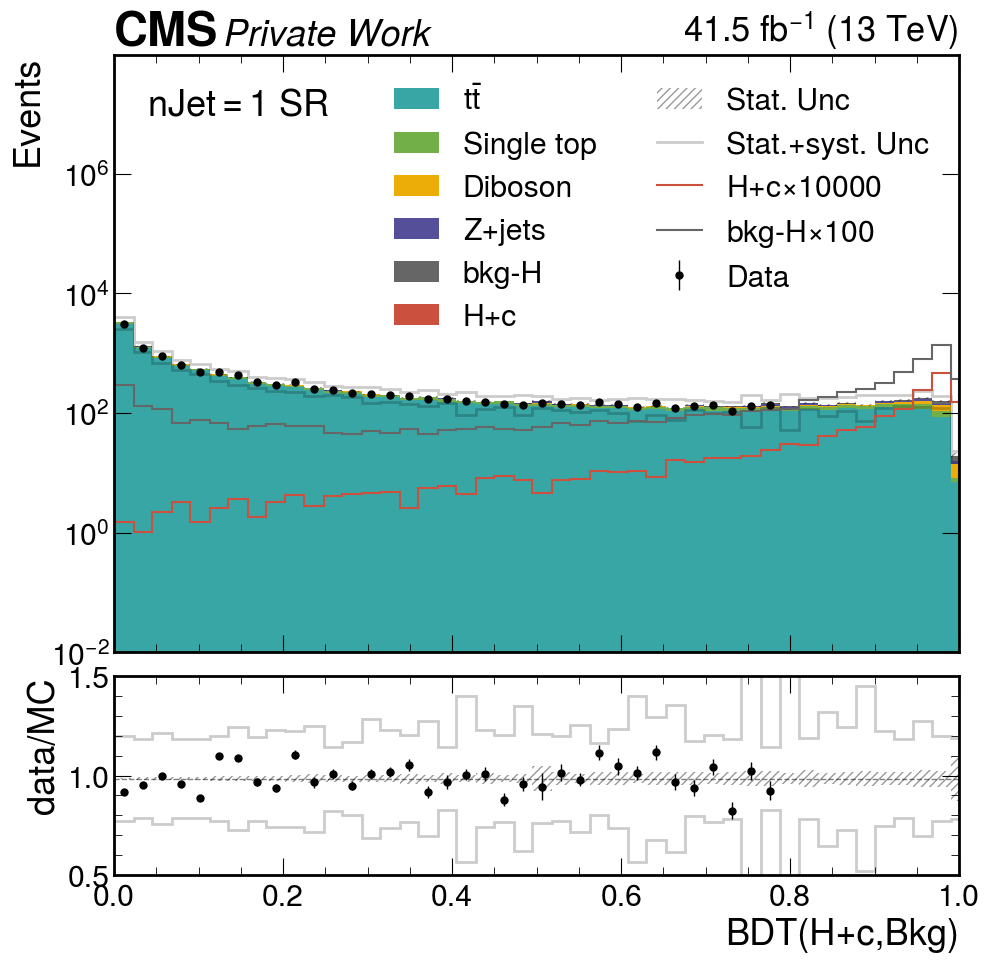

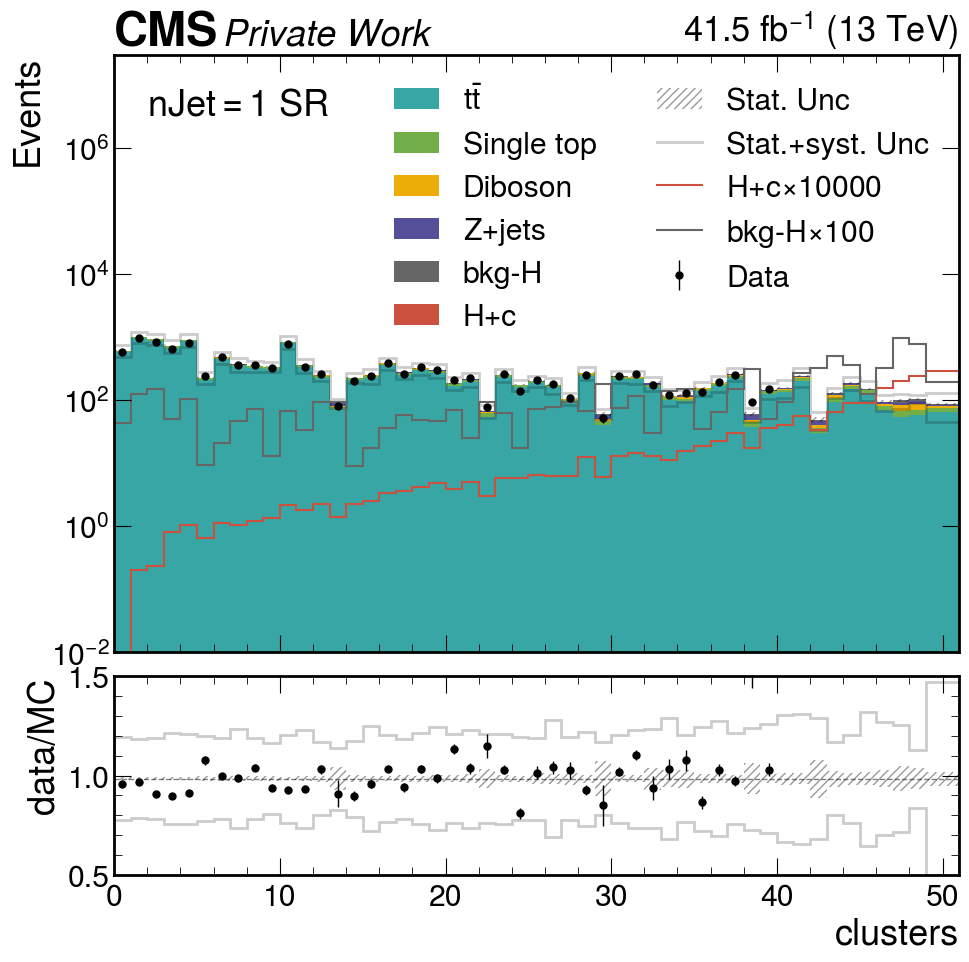

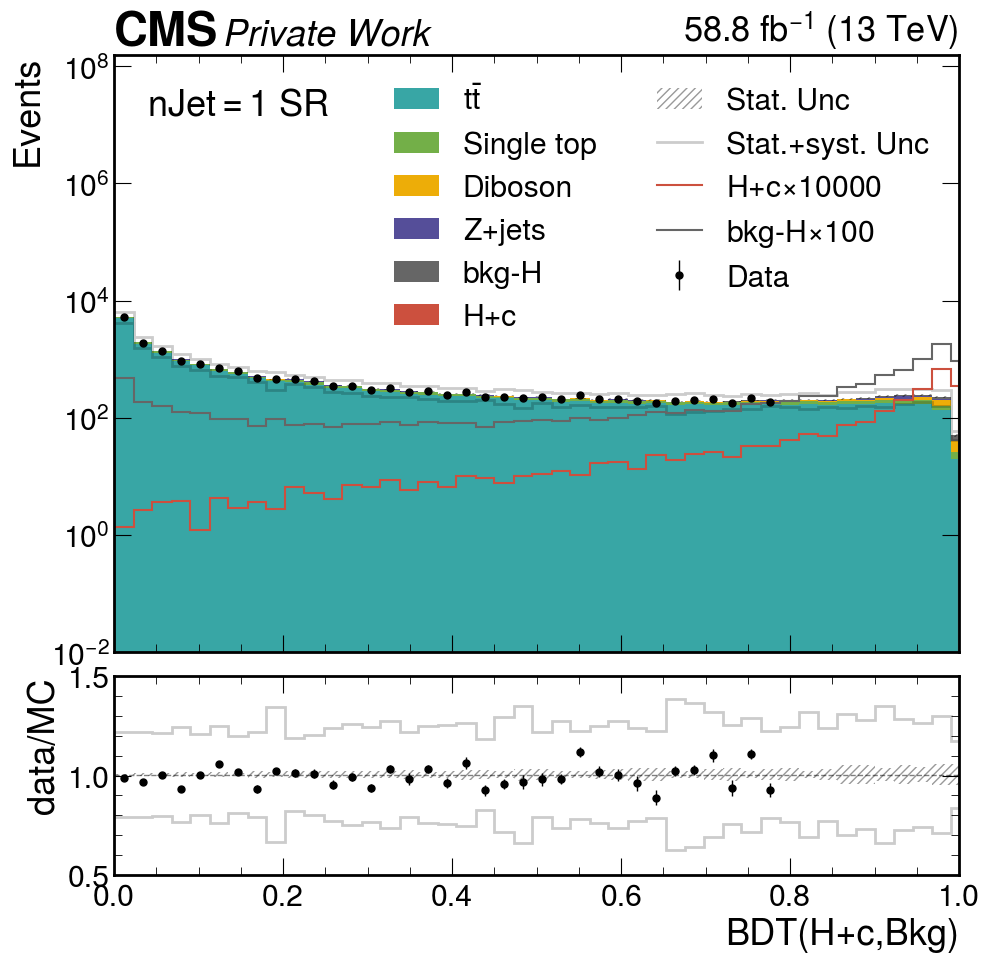

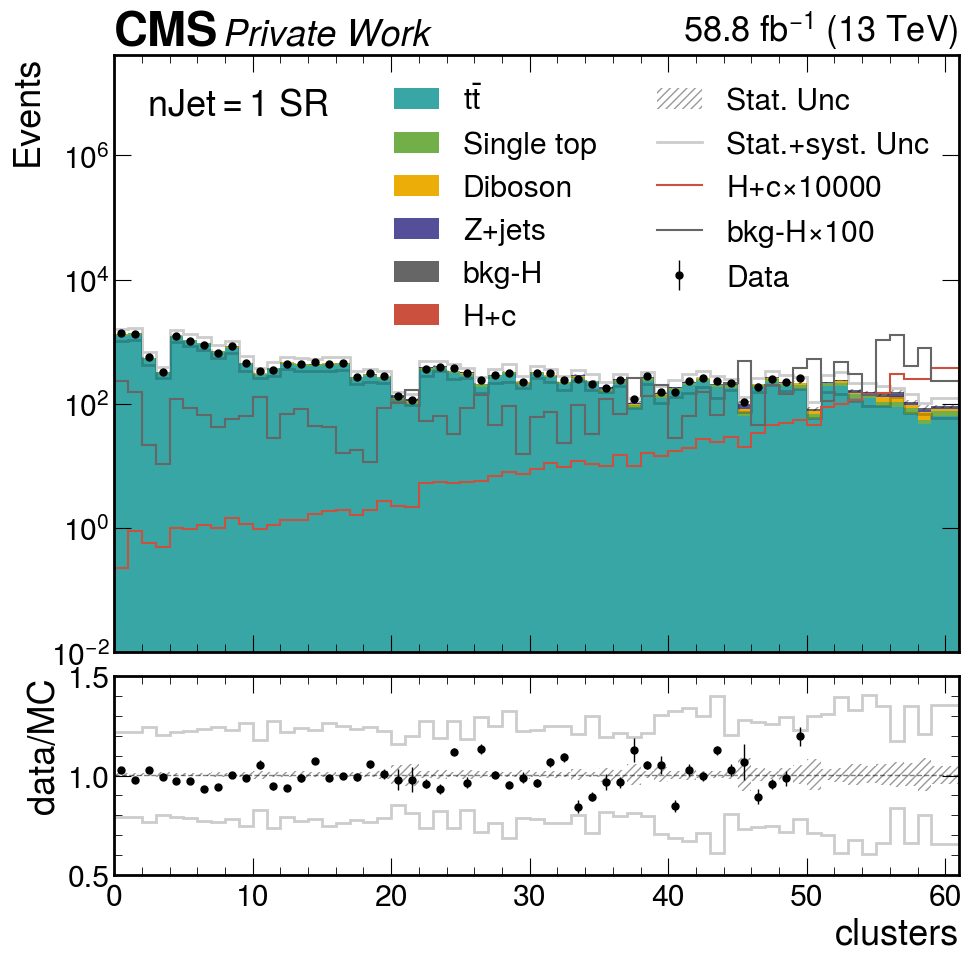

In [21]:

plt.style.use(hep.style.ROOT)
for year in lumis.keys():
    for shape in shapes.keys():
        f = uproot.open(f"../card_maker/cards/{year}_newCR_{year}/{shapes[shape]}")
        s="1D_13TeV" if "1D" in shape else "_13TeV_twoPOI"
        fsyst = uproot.open(f"../card_maker/cards/run2_newCR_run2/fitDiagnosticshc_emu_all{s}_mu1_.preFit.root")
        collated=f[shapes[shape].replace(".root","").replace("input","")]
        
        fig, ((ax), (rax)) = plt.subplots(
                        2, 1, gridspec_kw={"height_ratios": (3, 1)}, sharex=True
                    )
        hep.cms.label(
                "Private Work",
                data=True,
                lumi=lumis[year],
                loc=0,
                ax=ax,
            )
        fig.subplots_adjust(hspace=0.06, top=0.92, bottom=0.1, right=0.97)
        hep.histplot([collated[s]for s in color_map.keys()] ,histtype='fill',color=[color_map[s] for s in color_map.keys()],label=[name_map[s] for s in color_map.keys()],stack=True,ax=ax,flow=None)
        hmc,mcyerr=collated['hc'].values(),collated['hc'].variances()
        
       
        for s in color_map.keys():
            
            if s!="hc":
                hmc=hmc+collated[s].values()
                mcyerr=mcyerr+collated[s].variances()
        ax.stairs(np.sqrt(mcyerr)+hmc, edges=collated["hc"].axes[0].edges(), baseline=hmc-np.sqrt(mcyerr),**opts,label='Stat. Unc')
        ax.stairs(np.sqrt(fsyst[f'shapes_prefit/ch{list(lumis).index(year)+1}_{shape}/total'].variances()[:len(hmc)])+hmc, 
                  edges=collated["hc"].axes[0].edges(),
                  baseline=hmc-np.sqrt(fsyst[f'shapes_prefit/ch{list(lumis).index(year)+1}_{shape}/total'].variances()[:len(hmc)]),
                  **syst,label='Stat.+syst. Unc')
        print(len(hmc),len(fsyst[f'shapes_prefit/ch{list(lumis).index(year)+1}_{shape}/total'].variances()[fsyst[f'shapes_prefit/ch{list(lumis).index(year)+1}_{shape}/total'].variances()!=0]))
        ratio = np.sum(collated['data_obs'].values())/np.sum(hmc)
        # print(ratio)
        data,dataerr=collated["data_obs"].values(),np.sqrt(collated["data_obs"].variances())
        
        if "SR2_LM" in shape :
            data[-10:] = np.nan
            dataerr[-10:] = 0.
        if "SR_LM" in shape: 
            data[-5:] = np.nan 
            dataerr[-5:] = 0.
        hep.histplot(data,collated["hc"].axes[0].edges(),yerr=dataerr,histtype='errorbar',color='k',ax=ax,flow=None,label="Data")
        hep.histplot(collated["hc"].values()*10000,collated["hc"].axes[0].edges(),color=color_map["hc"],label="H+c$\\times$10000",ax=ax,flow=None)
        hep.histplot(collated["higgs"].values()*100,collated["hc"].axes[0].edges(),color=color_map["higgs"],label="bkg-H$\\times$100",ax=ax,flow=None)
        rax.set_ylim(0.5,1.5)
        
        ax.set_xlabel(None)
        rax.set_ylabel("data/MC")
        ax.set_ylabel("Events")
        ax.legend(ncols=2,loc='upper right')
        at = AnchoredText(reg[shape][0],  frameon=False,loc=2)
        ax.add_artist(at)
        ax.semilogy()
        if "SR" in shape:ax.semilogy()
        hep.mpl_magic(ax=ax)
        ax.set_ylim(bottom=0.01)
        
        
        rax.set_xlim(collated["hc"].axes[0].edges()[0],collated["hc"].axes[0].edges()[-1])
        
        hep.histplot(data/hmc,collated["hc"].axes[0].edges(),yerr=np.sqrt(dataerr/collated['data_obs'].values()**2+mcyerr/hmc**2),histtype='errorbar',color='k',ax=rax)
        rax.axhline(ratio,**other)
        
        print(np.sqrt(mcyerr)/hmc)
        rax.stairs(ratio+np.sqrt(mcyerr)/hmc, edges=collated["hc"].axes[0].edges(), baseline=ratio-np.sqrt(mcyerr)/hmc,**opts)
        rax.stairs(ratio+np.sqrt(fsyst[f'shapes_prefit/ch{list(lumis).index(year)+1}_{shape}/total'].variances()[:len(hmc)])/hmc, 
                  edges=collated["hc"].axes[0].edges(),
                  baseline=ratio-np.sqrt(fsyst[f'shapes_prefit/ch{list(lumis).index(year)+1}_{shape}/total'].variances()[:len(hmc)])/hmc,
                  **syst,label='Stat.+syst. Unc')
        rax.set_xlabel(reg[shape][1])
        # rax.fill_between((h.axes[0].edges[1:]+h.axes[0].edges[:-1])/2.,y1=np.sqrt(h.variances())/h.values()+1.,y2=1.-np.sqrt(h.variances())/h.values(),hatch='//',alpha=0.2,facecolor="none",step='pre')
        fig.savefig(f"{shape}_{year}.pdf")


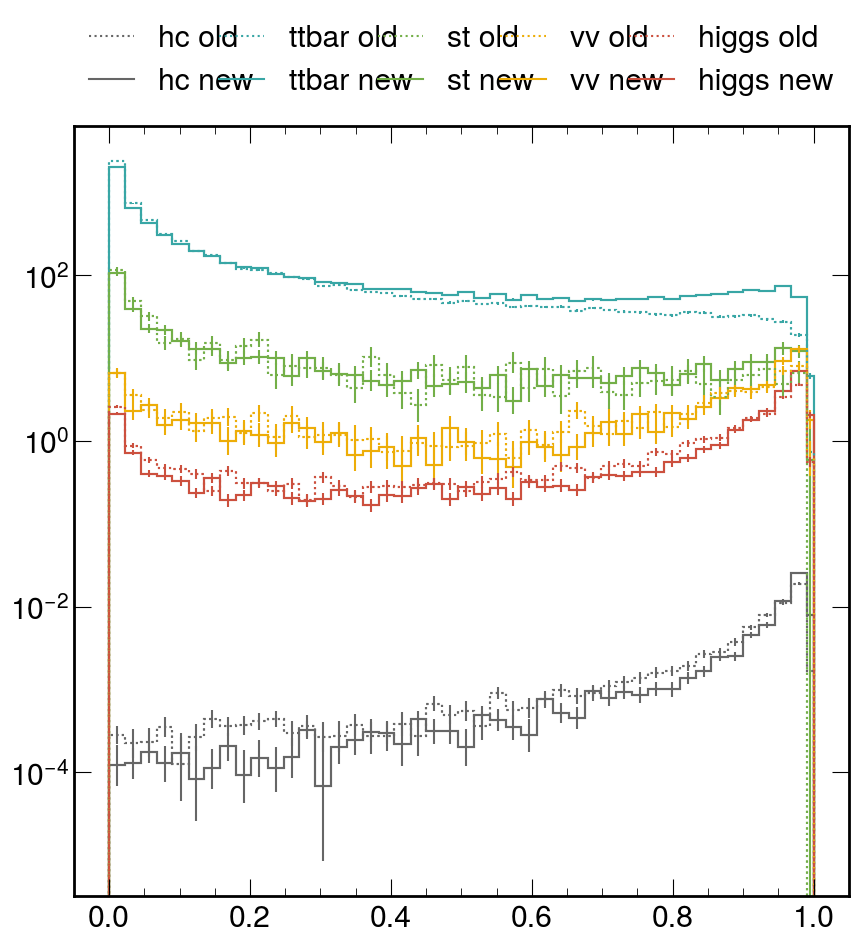

In [17]:
import mplhep as hep
import matplotlib.pyplot as plt
plt.style.use(hep.style.ROOT)

l=["hc;1","ttbar;1","st;1","vv;1","higgs;1"]

fig,ax=plt.subplots()
for s in l:
    hep.histplot(f2[f"hc_emu_1_13TeV/{s}"],label=s.replace(";1"," old"),color=color_map[s.replace(";1","")],ls=":",yerr=False,ax=ax)

    hep.histplot(f[f"hc_emu_2_13TeV/{s}"],label=s.replace(";1"," new"),color=color_map[s.replace(";1","")],yerr=False,ax=ax)
ax.semilogy()
# ax.legend(ncols=2)
ax.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
                mode="expand", borderaxespad=0, ncol=5)
# handles,l=ax.get_legend_handles_labels()
# from matplotlib import container
for s in l:
    hep.histplot(f[f"hc_emu_2_13TeV/{s}"],label=s.replace(";1"," new"),color=color_map[s.replace(";1","")],yerr=True,ax=ax)
for s in l:   
    hep.histplot(f2[f"hc_emu_1_13TeV/{s}"],label=s.replace(";1"," old"),ls=":",color=color_map[s.replace(";1","")],yerr=True,ax=ax)
# handles = [h[0] if isinstance(h, container.ErrorbarContainer) else h for h in handles]

# ax.legend(handles,l)
# h[0][1]#[0]

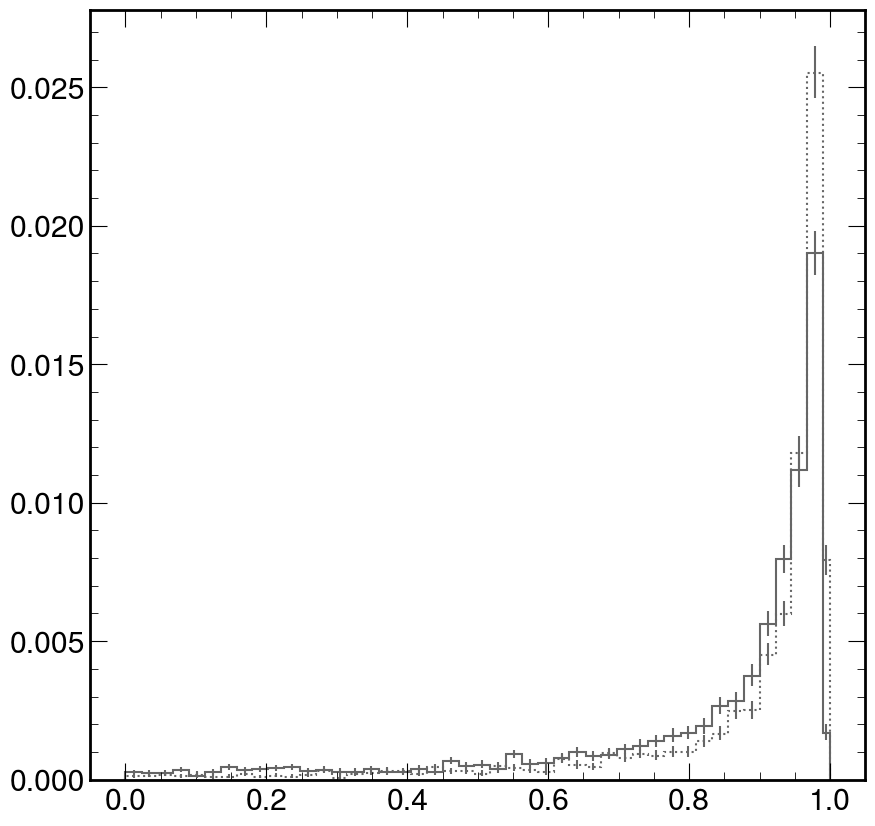

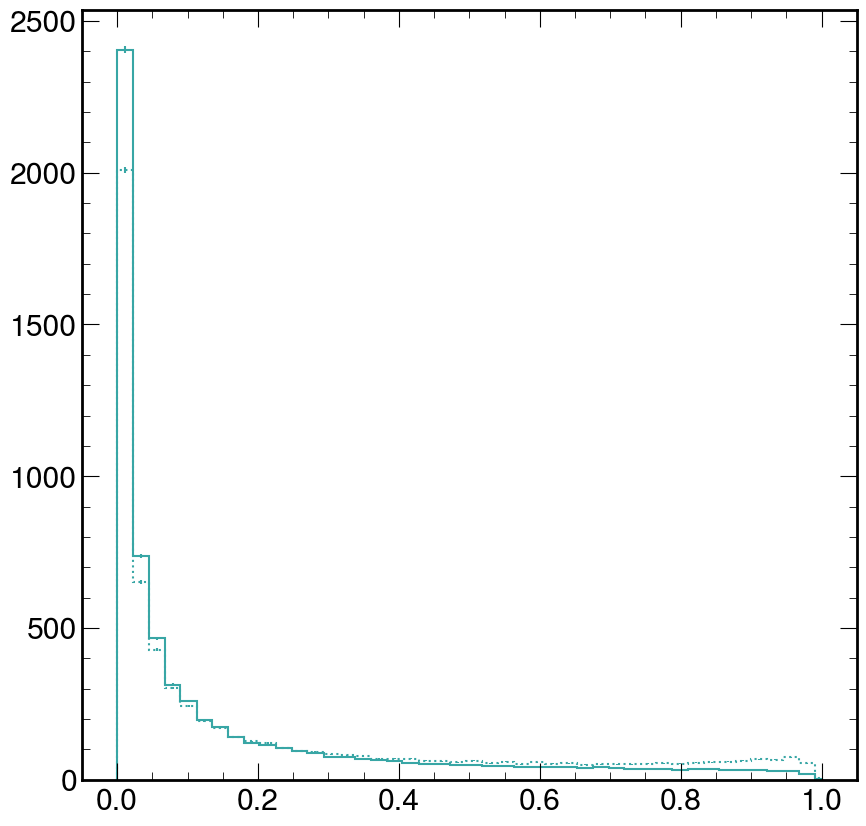

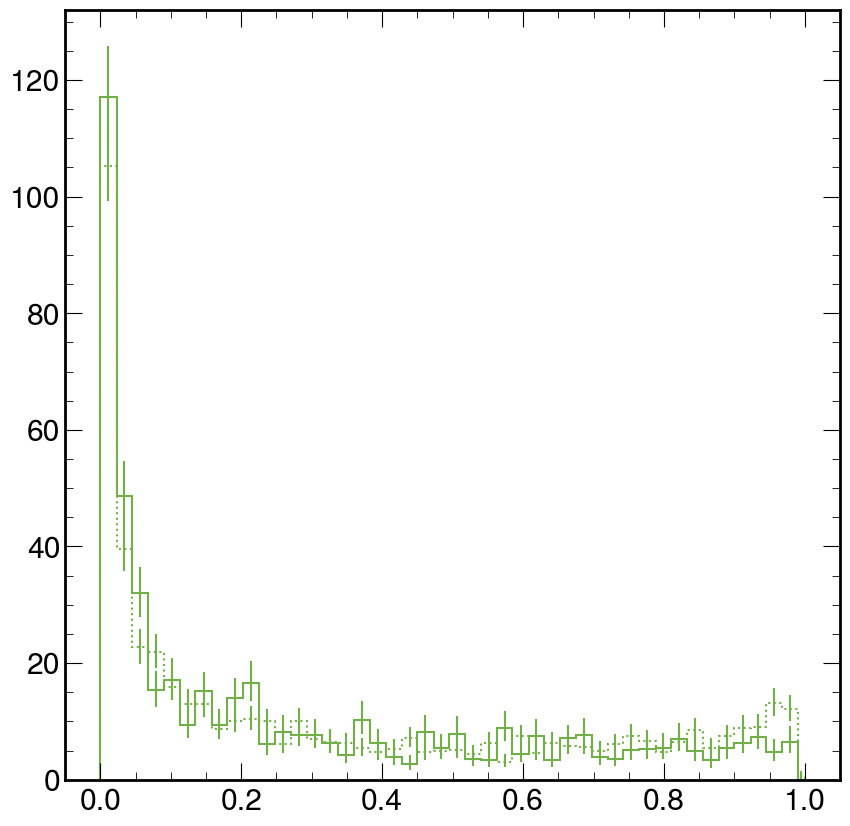

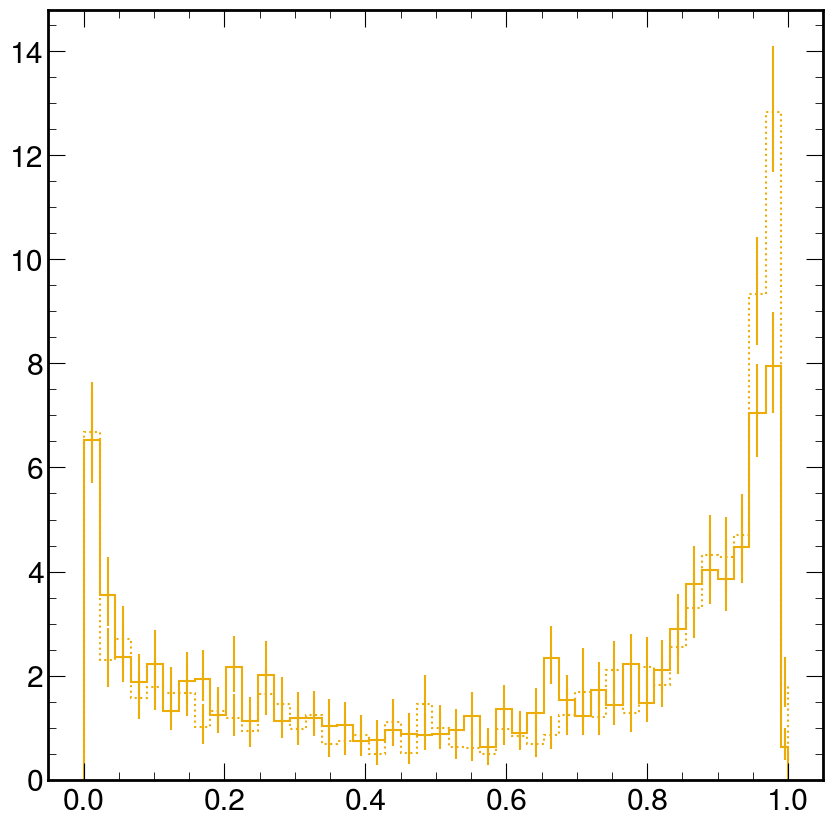

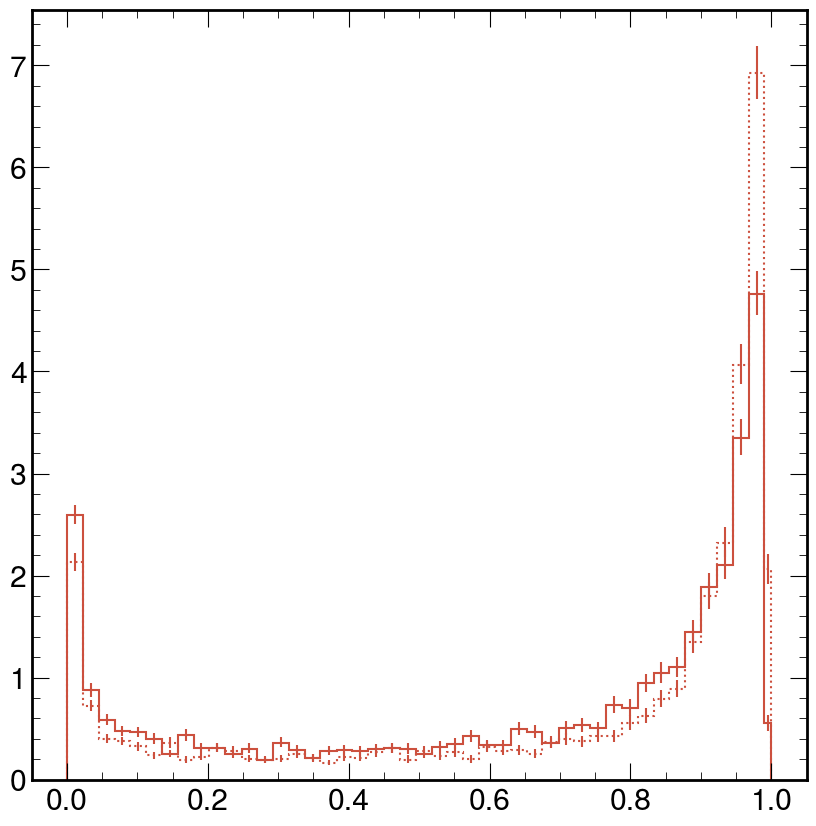

In [15]:
for s in l:
    fig,ax=plt.subplots()
    hep.histplot(f[f"hc_emu_2_13TeV/{s}"],label=s.replace(";1"," new"),ls=":",color=color_map[s.replace(";1","")],yerr=True,ax=ax)
    hep.histplot(f2[f"hc_emu_1_13TeV/{s}"],label=s.replace(";1"," old"),color=color_map[s.replace(";1","")],yerr=True,ax=ax)

## all

In [1]:
syst_list=['ttbar_weight',
 'PDFaS_weight',
 'ele_ID_2017',
 'mu_Iso_2017',
 'puweight_2017',
 'mu_ID_2017',
 'ele_Reco_2017',
 'mu_Reco_2017',
  'aS_weight',
 'L1prefireweight',
 'DeepJetC_Interp',
 'scalevar_3pt',
 'DeepJetC_PSWeightISR',
 'DeepJetC_jesTotal',
 'DeepJetC_Stat_2017',
 'UEPS_FSR',
 'DeepJetC_PSWeightFSR',
 'PDF_weight',
 'DeepJetC_XSec_BRUnc_WJets_c',
 'DeepJetC_XSec_BRUnc_DYJets_b',
 'DeepJetC_Extrap',
 'DeepJetC_LHEScaleWeight_muR',
 'DeepJetC_PUWeight',
 'DeepJetC_jer',
 'DeepJetC_XSec_BRUnc_DYJets_c',
 'scalevar_7pt',
 'UEPS_ISR',
 'DeepJetC_LHEScaleWeight_muF',
"JES_FlavorQCD",
"JES_RelativeBal",
"JES_HF",
"JES_BBEC1",
"JES_EC2",
"JES_Absolute",
    "JES_jes",
"JES_Absolute_2017",
"JES_HF_2017",
"JES_EC2_2017",
"JES_RelativeSample_2017",
"JES_BBEC1_2017",
 # 'JES_2017',
 'UES_2017',
 'JER_2017']
sample=["ttbar",'hc','st','vv','higgs','zjets']
def filter_strings(string_list, substr,start=False):
    # Create a filter condition using the "any" function and a generator expression
    filtered_list =[]
    for s in string_list:
        if start and s.startswith(substr): filtered_list.append(s)
        elif substr in s  and not start: filtered_list.append(s)
    return filtered_list

In [2]:
import matplotlib.pyplot as plt
import mplhep as hep
from coffea.util import load
output=load("MC_HLT_UL17_v04/output.coffea")
output_newHLT=load("MC_HLT_UL17_v03/output.coffea")

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fb47f2ce470>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

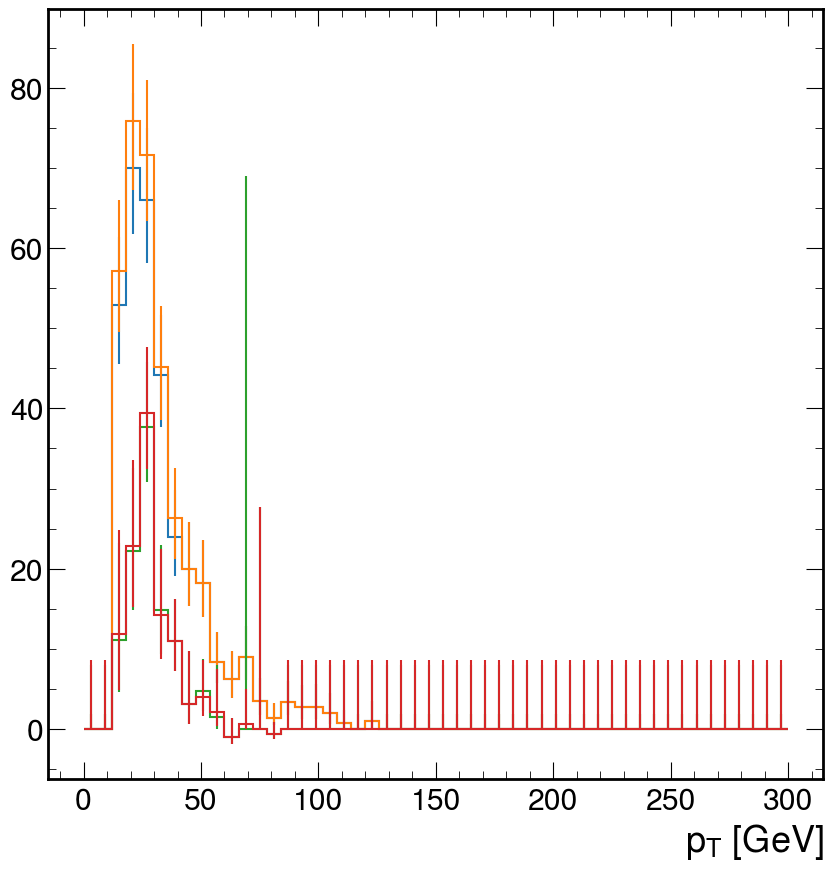

In [9]:
# output['TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8']['ele_pt']
hep.histplot(output['TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8']['ele_pt'][2,1,sum,:])
hep.histplot(output_newHLT['TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8']['ele_pt'][2,1,sum,:])
hep.histplot(output['HPlusCharm_4FS_MuRFScaleDynX0p50_HToWWTo2L2Nu_M125_TuneCP5_13TeV-amcatnloFXFX-pythia8']['ele_pt'][2,1,sum,:])
hep.histplot(output_newHLT['HPlusCharm_4FS_MuRFScaleDynX0p50_HToWWTo2L2Nu_M125_TuneCP5_13TeV-amcatnloFXFX-pythia8']['ele_pt'][2,1,sum,:])

In [10]:
import uproot

import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use(hep.style.ROOT)
from BTVNanoCommissioning.utils.xs_scaler import collate
from BTVNanoCommissioning.utils.plot_utils import load_coffea
import numpy as np
from BTVNanoCommissioning.helpers.xsection import xsection
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt, mplhep as hep
%load_ext autoreload
%autoreload 2
from BTVNanoCommissioning.utils.plot_utils import (
    isin_dict,
    check_config,
    load_coffea,
    load_default,
    rebin_and_xlabel,
    plotratio,
    errband_opts,
    autoranger,
    rebin_hist
)
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
output=load_coffea({"input":"MC_newCR_UL17_v01//*.coffea","lumi":41500},True)
output2=load_coffea({"input":"MC_HLTcheck_UL17_v01//*.coffea","lumi":41500},True)

In [15]:
mergemap={
    'ttbar':['TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8'],
    'hc':['HPlusCharm_4FS_MuRFScaleDynX0p50_HToWWTo2L2Nu_M125_TuneCP5_13TeV-amcatnloFXFX-pythia8']
}
HLT=collate(output2,mergemap)
old=collate(output,mergemap)

Text(0, 1, 'Events')

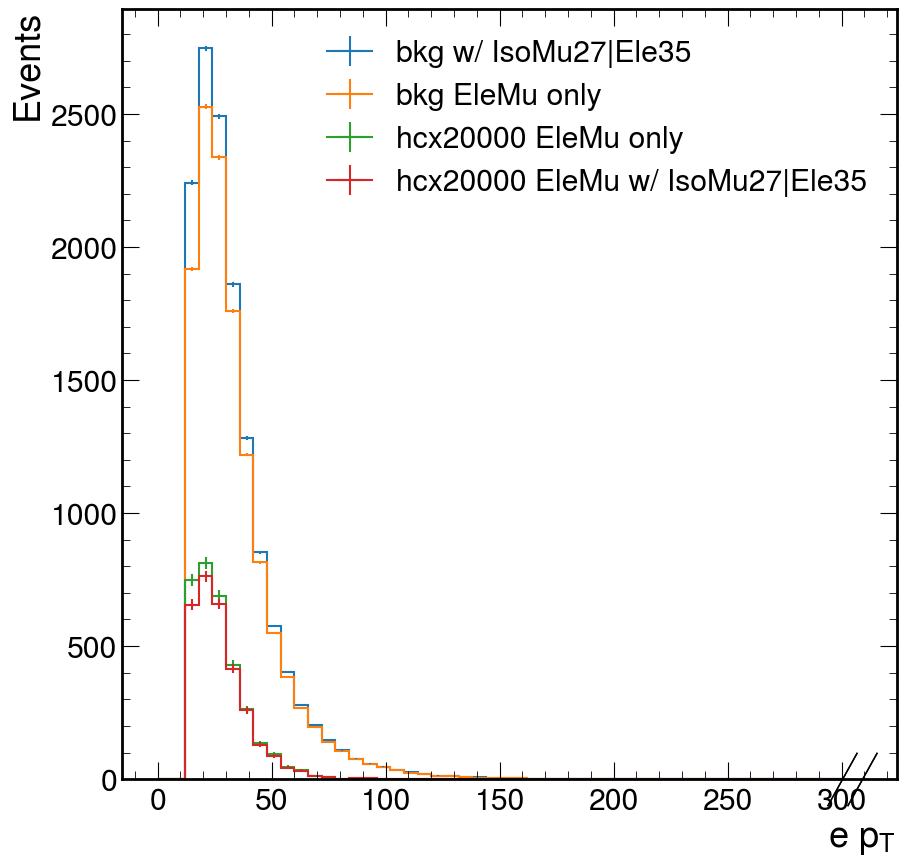

In [33]:
# fig, ((ax), (rax)) = plt.subplots(
#                     2, 1, gridspec_kw={"height_ratios": (3, 1)}, sharex=True
#                 )
hep.histplot(HLT['ttbar']['ele_pt'][2,1,sum,:],label='bkg w/ IsoMu27|Ele35')
hep.histplot(old['ttbar']['ele_pt'][2,1,sum,:],label='bkg EleMu only')#,ax=ax)
hep.histplot(HLT['hc']['ele_pt'][2,1,sum,:]*20000,label='hcx20000 EleMu only')#,ax=ax)
hep.histplot(old['hc']['ele_pt'][2,1,sum,:]*20000,label='hcx20000 EleMu w/ IsoMu27|Ele35')#,ax=ax)
plt.legend()
plt.xlabel("e $p_T$ ")
plt.ylabel("Events")
# HLT['ttbar'][2,1,sum,:].values()
# rax.errorbar(x=old['hc']['ele_pt'][2,1,sum,:].axes[0].centers,y=old['hc']['ele_pt'][2,1,sum,:].values()/np.sqrt(old['ttbar']['ele_pt'][2,1,sum,:].values()))
# rax.errorbar(x=HLT['hc']['ele_pt'][2,1,sum,:].axes[0].centers,y=HLT['hc']['ele_pt'][2,1,sum,:].values()/np.sqrt(HLT['ttbar']['ele_pt'][2,1,sum,:].values()))
# plotratio(collated['data_obs'][var][axes]+collated['data_obs'][var][axes2],hmc,ax=rax)

/tmp/ipykernel_41162/3724335783.py:1: RuntimeWarning: invalid value encountered in divide
  plt.errorbar(x=old['hc']['ele_pt'][2,1,sum,:].axes[0].centers,y=(HLT['hc']['ele_pt'][2,1,sum,:].values()/np.sqrt(HLT['ttbar']['ele_pt'][2,1,sum,:].values()))/(old['hc']['ele_pt'][2,1,sum,:].values()/np.sqrt(old['ttbar']['ele_pt'][2,1,sum,:].values())))
/tmp/ipykernel_41162/3724335783.py:2: RuntimeWarning: invalid value encountered in divide
  (HLT['hc']['ele_pt'][2,1,sum,:].values()/np.sqrt(HLT['ttbar']['ele_pt'][2,1,sum,:].values()))/(old['hc']['ele_pt'][2,1,sum,:].values()/np.sqrt(old['ttbar']['ele_pt'][2,1,sum,:].values()))


array([       nan,        nan, 1.0552813 , 1.02414038, 1.01607343,
       1.00745164, 0.98961507, 1.01257585, 1.06519587, 1.0480221 ,
       1.00745119, 1.05521684, 0.9112296 , 1.59010043, 0.98593201,
       0.99165137, 1.30088067, 0.72200113, 1.64629638, 1.44200144,
       0.87503947, 0.97814573, 1.00278668,        nan,        nan,
       0.94364295,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan])

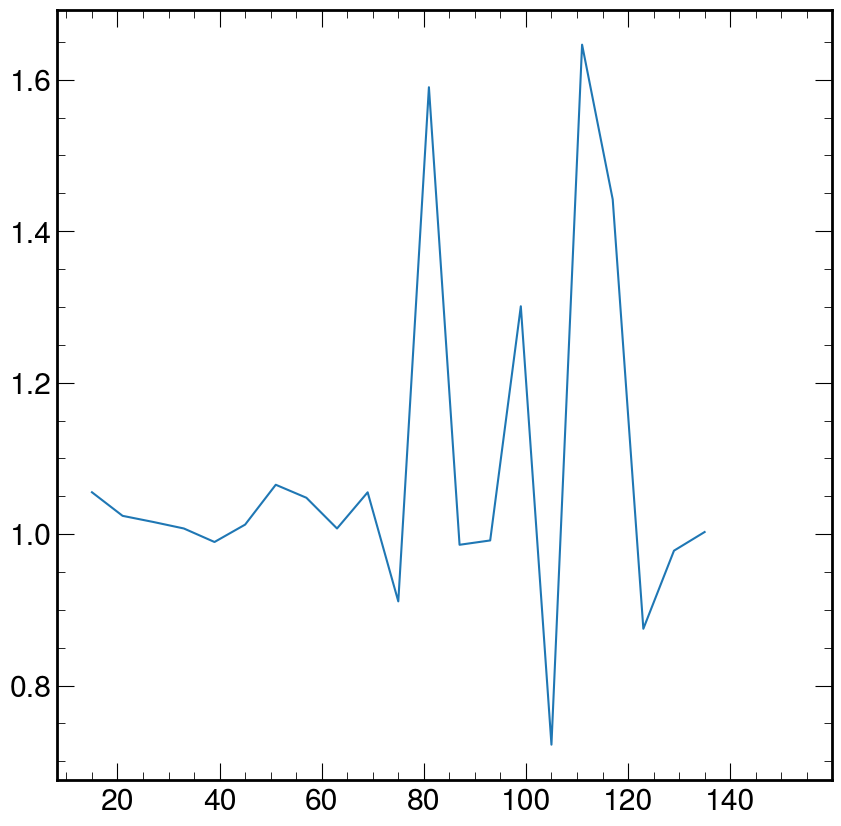

In [29]:
plt.errorbar(x=old['hc']['ele_pt'][2,1,sum,:].axes[0].centers,y=(HLT['hc']['ele_pt'][2,1,sum,:].values()/np.sqrt(HLT['ttbar']['ele_pt'][2,1,sum,:].values()))/(old['hc']['ele_pt'][2,1,sum,:].values()/np.sqrt(old['ttbar']['ele_pt'][2,1,sum,:].values())))
(HLT['hc']['ele_pt'][2,1,sum,:].values()/np.sqrt(HLT['ttbar']['ele_pt'][2,1,sum,:].values()))/(old['hc']['ele_pt'][2,1,sum,:].values()/np.sqrt(old['ttbar']['ele_pt'][2,1,sum,:].values()))

UES_2017 ['ttbar_CMS_UES_2018_13TeVUp;1', 'ttbar_CMS_UES_2018_13TeVDown;1']
UES_2017 ['hc_CMS_UES_2018_13TeVUp;1', 'hc_CMS_UES_2018_13TeVDown;1']
UES_2017 ['st_CMS_UES_2018_13TeVUp;1', 'st_CMS_UES_2018_13TeVDown;1']
UES_2017 ['vv_CMS_UES_2018_13TeVUp;1', 'vv_CMS_UES_2018_13TeVDown;1']
UES_2017 ['higgs_CMS_UES_2018_13TeVUp;1', 'higgs_CMS_UES_2018_13TeVDown;1']
UES_2017 ['zjets_CMS_UES_2018_13TeVUp;1', 'zjets_CMS_UES_2018_13TeVDown;1']


/nfs/dust/cms/user/milee/CoffeaRunner/src/BTVNanoCommissioning/utils/plot_utils.py:551: RuntimeWarning: divide by zero encountered in divide
  rsumw = sumw_num / sumw_denom
/nfs/dust/cms/user/milee/CoffeaRunner/src/BTVNanoCommissioning/utils/plot_utils.py:551: RuntimeWarning: invalid value encountered in divide
  rsumw = sumw_num / sumw_denom
/nfs/dust/cms/user/milee/CoffeaRunner/src/BTVNanoCommissioning/utils/plot_utils.py:560: RuntimeWarning: divide by zero encountered in divide
  rsumw_err = np.abs(poisson_interval(rsumw, sumw2_num / sumw_denom**2) - rsumw)
/nfs/dust/cms/user/milee/CoffeaRunner/src/BTVNanoCommissioning/utils/plot_utils.py:560: RuntimeWarning: invalid value encountered in divide
  rsumw_err = np.abs(poisson_interval(rsumw, sumw2_num / sumw_denom**2) - rsumw)
/nfs/dust/cms/user/milee/CoffeaRunner/src/BTVNanoCommissioning/utils/plot_utils.py:338: RuntimeWarning: invalid value encountered in divide
  scale[sumw != 0] = sumw2[sumw != 0] / sumw[sumw != 0]
/nfs/dust/cms/us

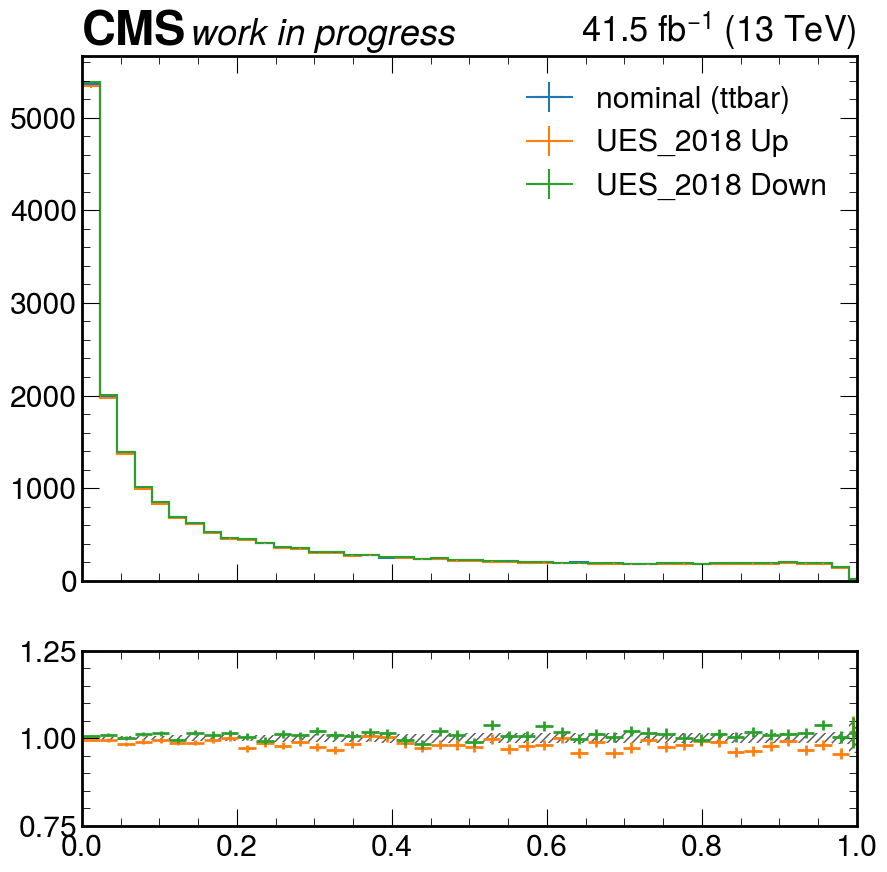

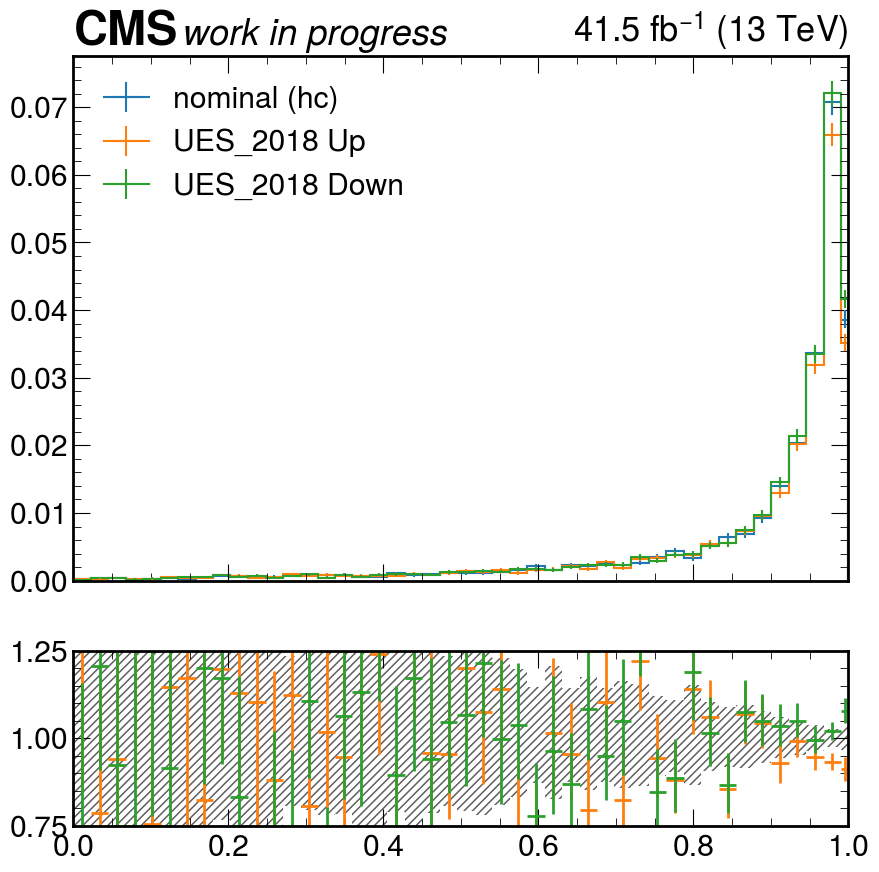

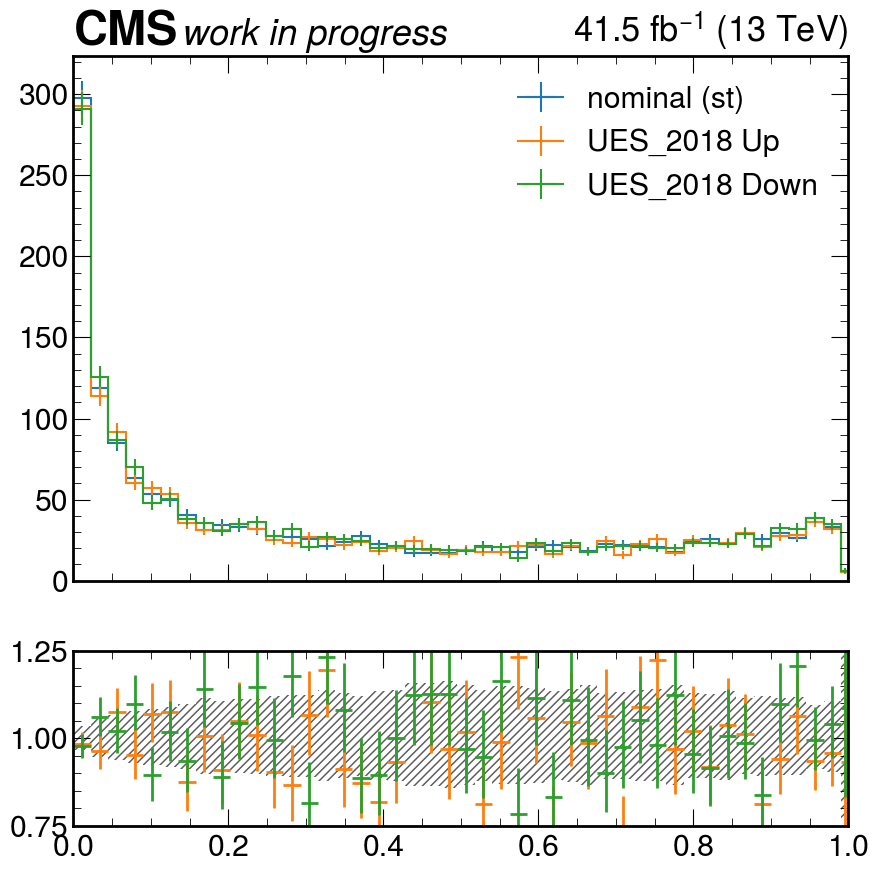

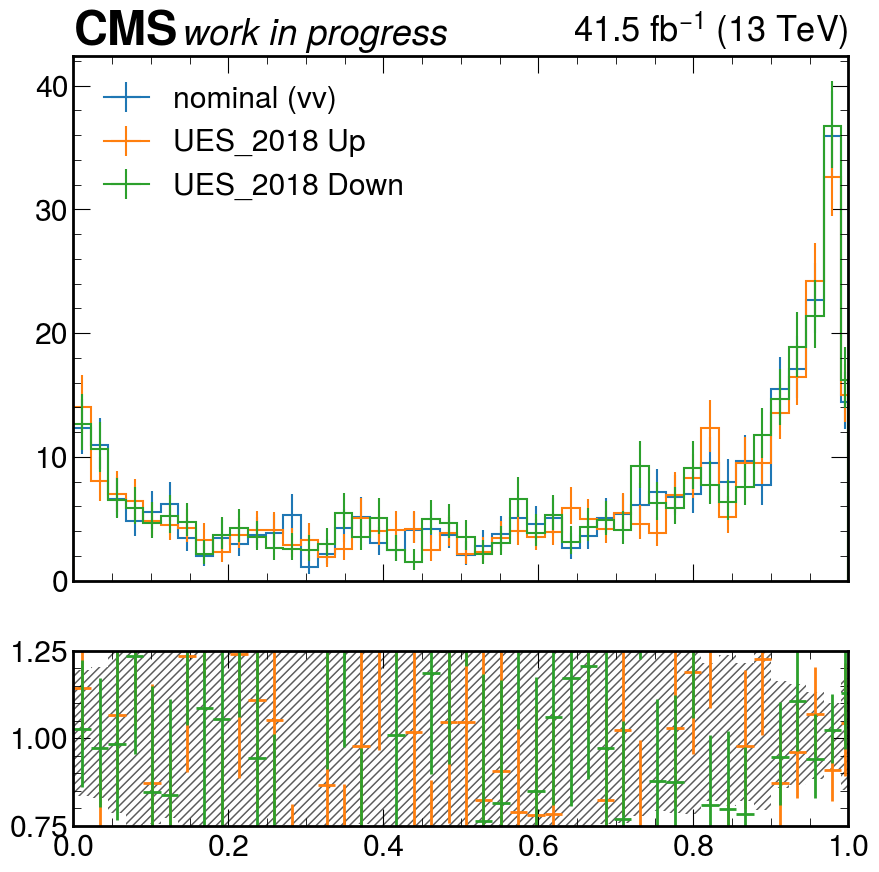

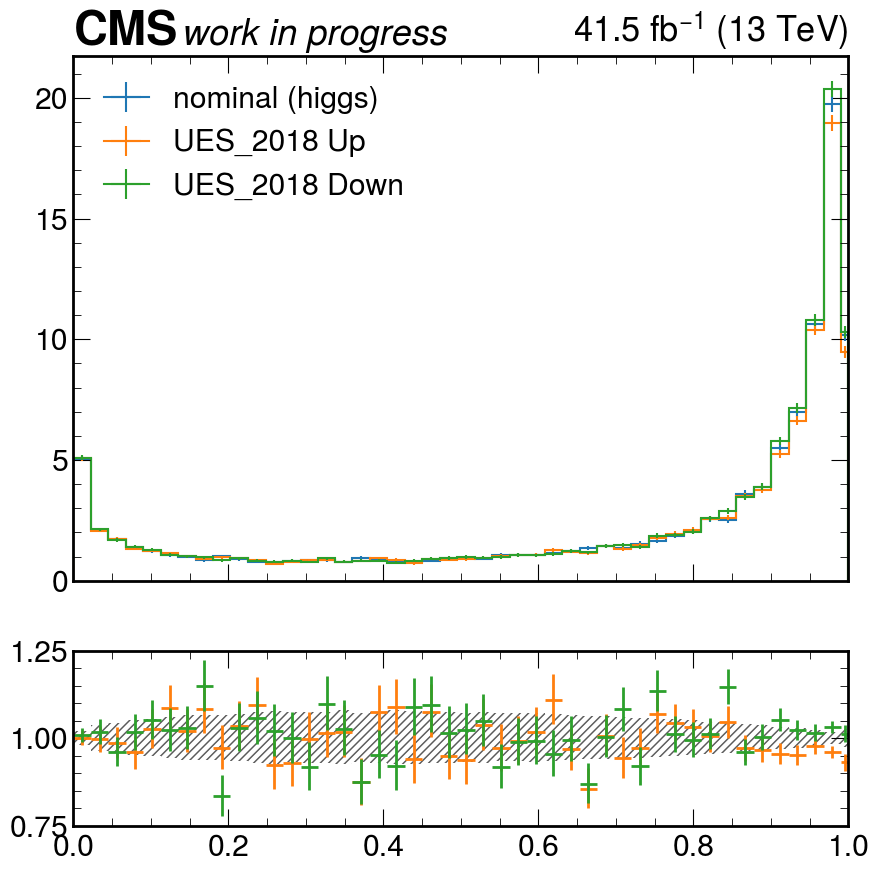

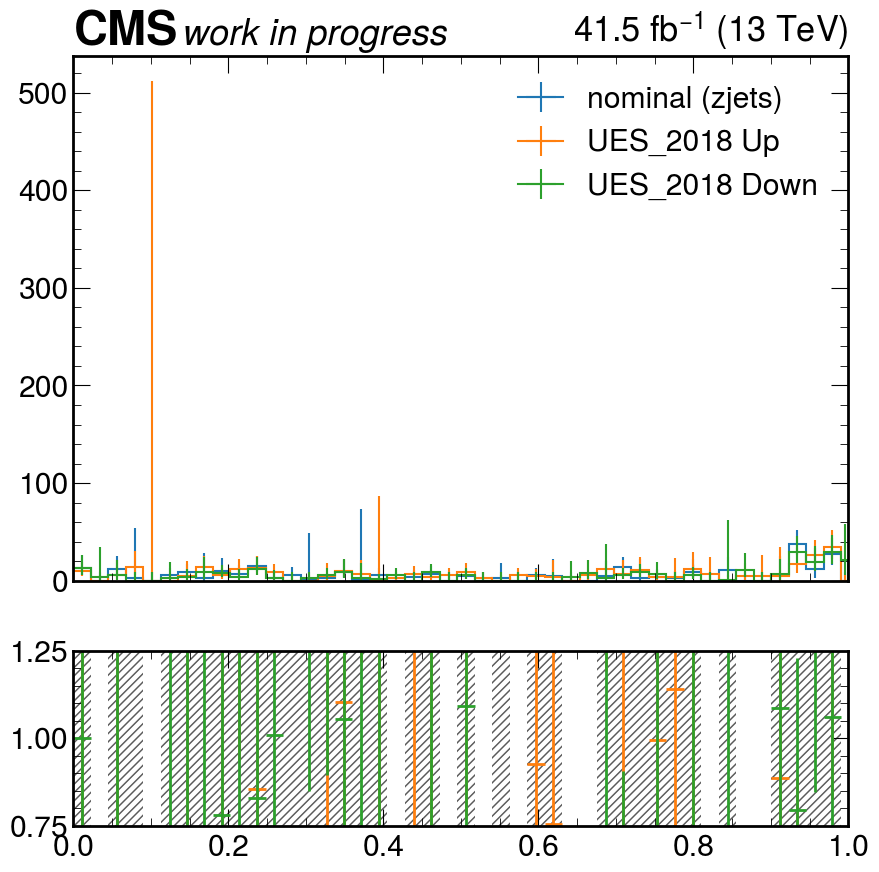

In [17]:
years=["2018"]#,"2016_postVFP","2017","2018"]
regions=["SR2_LM_1D"]#,"SR2_LM_1D","SR_LM_1D","SR2_LM","SR_LM","top_CR_lowmT"]
for year in years:
    for region in regions: 
        
    # pdf = PdfPages(f'{year}_{region}.pdf')
        f=uproot.open(f"/nfs/dust/cms/user/milee/card_maker/shape/{year}_{region}_template_BDT_{region}_0703_newBDT.root")
        
        
        for s in sample:
            for syst  in [ 'UES_2017']:#syst_list:
                hsyst = filter_strings(f.keys(),s,True)
                hsyst = filter_strings(hsyst,syst.replace("2017",year))
                print(syst,hsyst)
                for i,h in enumerate(hsyst):
                    if i==0:
                        fig, ((ax), (rax)) = plt.subplots(
                    2, 1, gridspec_kw={"height_ratios": (3, 1)}, sharex=True
                )
                        hep.cms.label(
                                "work in progress",
                                data=True,
                                lumi=41500/1000,
                                com="13",
                                loc=0,
                                ax=ax,
                            )
                        hep.histplot(f[f'{s};1'],label=f"nominal ({s})",ax=ax)
                    labels=h.split("13TeV")[0].split("CMS_")[1][:-1]+" "+h.split("13TeV")[1].replace(";1","")
                    hep.histplot(f[h],label=labels,ax=ax)
                    plotratio(f[h].values(),f[f'{s};1'].values(),
                              numw2=f[h].variances(),denomw2=f[f'{s};1'].variances(),edges=f[h].axes[0].edges(),
                              data_is_np=True, error_opts={"lw":2,"marker":None,"color": ax.get_lines()[2*(i+1)].get_color()},
                              ax=rax,clear=False,xerr=True)
                    
                    ax.legend()
                    rax.set_ylim(0.75,1.25)
                    rax.set_xlim(f[h].axes[0].edges()[0],f[h].axes[0].edges()[-1])